CIS 2450 FINAL PROJECT

###Class Setup

In [ ]:
#keywords used to search for in each category
#strong= +3, medium= +2, weak= +1,
archetype_keywords = {

    "study_focus": {
        "strong": ["lofi", "lo-fi", "study", "focus", "instrumental", "deep focus"],
        "medium": ["beats", "ambient", "coding", "work", "concentration", "productivity", "flow"],
        "weak": ["calm", "chill", "background", "reading", "quiet", "brain", "minimal", "relax"]
    },

    "heartbreak_sad": {
        "strong": ["sad", "heartbreak", "breakup", "cry", "crying"],
        "medium": ["alone", "lonely", "miss", "missing", "hurt", "pain", "lost", "regret"],
        "weak": ["blue", "down", "emotional", "feels", "feelings", "melancholy", "dark"]
    },

    "summertime_party": {
        "strong": ["summer", "party", "beach", "pool"],
        "medium": ["vacation", "sun", "sunny", "tropical", "island", "daydrink", "bbq"],
        "weak": ["vibes", "fun", "happy", "lit", "dance", "weekend", "drive", "outside"]
    },

    "rustic_nostalgia": {
        "strong": ["country", "americana", "folk"],
        "medium": ["backroad", "truck", "hometown", "southern", "porch", "bonfire"],
        "weak": ["acoustic", "memories", "home", "roots", "friends", "family", "simple"]
    },

    "jazz_lounge": {
        "strong": ["jazz", "lounge", "bossa", "swing"],
        "medium": ["blues", "soul", "cocktail", "piano", "sax", "standards"],
        "weak": ["chill", "smooth", "classy", "dinner", "night", "evening", "wine"]
    },

    "hype_rap": {
        "strong": ["rap", "hiphop", "hip-hop", "trap", "drill"],
        "medium": ["hype", "gym", "workout", "turnup", "turn up", "beast", "grind"],
        "weak": ["energy", "bangers", "fire", "bass", "lit", "hard", "aggressive", "flex"]
    }
}

archetypes = ["study_focus", "heartbreak_sad","summertime_party",
              "rustic_nostalgia", "jazz_lounge", "hype_rap"]

#Song Audio Data Collection

###Download Datasets

In [ ]:
import os
import json
import re
import polars as pl
import kagglehub
import numpy as np

print("downloading datasets")

# Download Spotify Million Playlist Dataset
mpd_base_path = kagglehub.dataset_download("himanshuwagh/spotify-million")

# Dynamically find the correct BASE_PATH containing the JSON files
BASE_PATH = None
for root, dirs, files in os.walk(mpd_base_path):
    if any(f.endswith('.json') for f in files):
        BASE_PATH = root
        break

print("MPD Path:", BASE_PATH)

# Download 1.2M Spotify Song Dataset
dataset_path = kagglehub.dataset_download("rodolfofigueroa/spotify-12m-songs")
tracks_12m_path = os.path.join(dataset_path, "tracks_features.csv")
print("1.2M Features Path:", tracks_12m_path)

downloading datasets


100%|██████████| 5.20G/5.20G [01:08<00:00, 81.3MB/s]

Extracting files...


MPD Path: /root/.cache/kagglehub/datasets/himanshuwagh/spotify-million/versions/1/data


100%|██████████| 97.4M/97.4M [00:00<00:00, 132MB/s]

Extracting files...


1.2M Features Path: /root/.cache/kagglehub/datasets/rodolfofigueroa/spotify-12m-songs/versions/1/tracks_features.csv


###Exclusions

In [ ]:
# Exclusions for playlist names of specific archetypes
exclusions = {
    "heartbreak_sad": ["crystal", "ambassador"],
    "hype_rap": ["wrap", "therapy", "not rap", "crap", "choreography"],
    "rustic_nostalgia": ["not country"]
}

###MPD Track Extraction

In [ ]:
print("MPD Extraction")
TRACKS_PER_ARCHETYPE = 150000

# scores a playlist based on strength and number of keyword matches
def score_playlist(playlist_name, keyword_dict):
    score = 0
    matched_keywords = []
    for word in keyword_dict["strong"]:
        if word in playlist_name:
            score += 3
            matched_keywords.append(word)
    for word in keyword_dict["medium"]:
        if word in playlist_name:
            score += 2
            matched_keywords.append(word)
    for word in keyword_dict["weak"]:
        if word in playlist_name:
            score += 1
            matched_keywords.append(word)
    return (score, matched_keywords)

extracted_tracks = {arch: [] for arch in archetypes}
track_counts = {arch: 0 for arch in archetypes}

# determines if we've met the target for all archetypes
def all_targets_met():
    return all(count >= TRACKS_PER_ARCHETYPE for count in track_counts.values())

for root_dir, dirs, files in os.walk(BASE_PATH):
    for filename in files:
        if not filename.endswith(".json"):
            continue

        if all_targets_met():
            break

        filepath = os.path.join(root_dir, filename)
        counts_summary = ", ".join([f"{arch}: {count}" for arch, count in track_counts.items()])
        print(f"Scanning: {filename} | {counts_summary}")

        try:
            with open(filepath, 'r', encoding='utf-8') as f:
                data = json.load(f)
        except Exception as e:
            print(f"Error reading {filename}: {e}")
            continue

        for playlist in data.get("playlists", []):
            playlist_name = str(playlist.get("name", "")).lower().strip()
            scores = {}

            # collect scores for all archetypes we're still collecting
            for archetype in archetypes:
                # don't collect more if already have twice the minimum amount
                if track_counts[archetype] >= 2*TRACKS_PER_ARCHETYPE:
                    continue
                score, matches = score_playlist(playlist_name, archetype_keywords[archetype])

                if archetype in exclusions:
                    # If any bad phrase for this archetype is found in the playlist name, skip it
                    if any(bad_phrase in playlist_name for bad_phrase in exclusions[archetype]):
                        continue

                if score > 0:
                    scores[archetype] = (score, matches)

            if not scores:
                continue

            best_archetype = max(scores, key=lambda a: scores[a][0])
            best_score, best_matches = scores[best_archetype]

            # not a strong match, so continue
            if best_score < 3:
                continue

            archetype = best_archetype
            tracks = playlist.get("tracks", [])

            for track in tracks:
                raw_uri = track.get("track_uri", "")
                track_id = raw_uri.split(":")[-1] if ":" in raw_uri else raw_uri

                extracted_tracks[archetype].append({
                    'archetype': archetype,
                    'matched_keywords': ", ".join(best_matches),
                    'match_score': best_score,
                    'playlist_name': playlist.get("name"),
                    'track_name': track.get("track_name", "Unknown"),
                    'artist_name': track.get("artist_name", "Unknown"),
                    'spotify_track_id': track_id
                })
                track_counts[archetype] += 1

                if track_counts[archetype] >= TRACKS_PER_ARCHETYPE:
                    break

    if all_targets_met():
        break

print("\nEXTRACTION COMPLETE")
for arch, count in track_counts.items():
    print(f" - {arch}: {count}")

# Save to CSV
all_tracks_list = []
for arch in archetypes:
    all_tracks_list.extend(extracted_tracks[arch])

df_all = pl.DataFrame(all_tracks_list)

# add new column with sum of all match_score's for that specific track within that archetype
df_all = df_all.with_columns(
    total_arch_score=pl.col('match_score').sum().over(['archetype', 'spotify_track_id'])
)

# Sort by archetype and track ID, then by match_score descending
df_all = df_all.sort(
    ['archetype', 'spotify_track_id', 'match_score'],
    descending=[False, False, True]
)

# Drop intra-archetype duplicates, keeping first row (which now holds the max match_score)
df_all = df_all.unique(
    subset=['archetype', 'spotify_track_id'],
    keep='first'
)

print("\nTracks per archetype after intra-archetype aggregation:\n", df_all['archetype'].value_counts())

output_file = "mpd_tracks.csv"
#Note: mpd_tracks has columns 'archetype', 'matched_keywords', 'match_score',
#'playlist_name', 'track_name', 'artist_name', 'spotify_track_id'

df_all.write_csv(output_file)
print(f"\nSaved {len(df_all)} total tracks to '{output_file}'")

MPD Extraction
Scanning: mpd.slice.583000-583999.json | study_focus: 0, heartbreak_sad: 0, summertime_party: 0, rustic_nostalgia: 0, jazz_lounge: 0, hype_rap: 0
Scanning: mpd.slice.185000-185999.json | study_focus: 612, heartbreak_sad: 525, summertime_party: 4360, rustic_nostalgia: 1077, jazz_lounge: 82, hype_rap: 1077
Scanning: mpd.slice.439000-439999.json | study_focus: 1133, heartbreak_sad: 901, summertime_party: 7455, rustic_nostalgia: 4302, jazz_lounge: 517, hype_rap: 2542
Scanning: mpd.slice.756000-756999.json | study_focus: 1784, heartbreak_sad: 1101, summertime_party: 10321, rustic_nostalgia: 5485, jazz_lounge: 783, hype_rap: 4772
Scanning: mpd.slice.311000-311999.json | study_focus: 2002, heartbreak_sad: 1423, summertime_party: 13201, rustic_nostalgia: 8864, jazz_lounge: 1134, hype_rap: 5869
Scanning: mpd.slice.998000-998999.json | study_focus: 2404, heartbreak_sad: 1769, summertime_party: 16341, rustic_nostalgia: 10520, jazz_lounge: 1666, hype_rap: 6877
Scanning: mpd.slice.15

###Join with Million Tracks dataset

In [ ]:
# Load the 1.2M dataset
df_12m = pl.read_csv(tracks_12m_path)
print("Loaded 1.2M dataset")

# Load our single extracted dataset
df_all_scraped = pl.read_csv("mpd_tracks.csv")
initial_count = len(df_all_scraped)

print(f"Pre-join: {initial_count}")

# Pass 1: ID match
print("\nPass 1")
merged_id = df_all_scraped.join(
    df_12m, left_on='spotify_track_id', right_on='id', how='inner'
)
print(f"ID matched {len(merged_id)} rows.")

# Pass 2: Name and Artist Match
print("\nPass 2")
unmatched_scraped = df_all_scraped.join(
    merged_id, on='spotify_track_id', how='anti'
)

# Clean strings for merging
unmatched_scraped = unmatched_scraped.with_columns(
    clean_track=pl.col('track_name').cast(pl.String).str.to_lowercase().str.strip_chars(),
    clean_artist=pl.col('artist_name').cast(pl.String).str.to_lowercase().str.strip_chars()
)

df_12m = df_12m.with_columns(
    clean_track=pl.col('name').cast(pl.String).str.to_lowercase().str.strip_chars(),
    clean_artist=(
        pl.col('artists').cast(pl.String).str.to_lowercase()
        .str.replace_all(r"[\[\]\'\"]", "")
        .str.split(',')
        .list.first()
        .str.strip_chars()
    )
)

# Secondary merge
merged_string = unmatched_scraped.join(
    df_12m, on=['clean_track', 'clean_artist'], how='inner'
).drop(['clean_track', 'clean_artist'])

print(f"Name matched {len(merged_string)} rows")

# Finalizing dataset
df_final = pl.concat([merged_id, merged_string], how='diagonal')

# Clean out compilation duplicates
df_final = df_final.unique(subset=['archetype', 'spotify_track_id'], keep='first')

#df has cols:
#
#'archetype' [String], 'matched_keywords' [comma-separated String],
#'match_score' [int], 'playlist_name' [String], 'track_name' [String],
# 'artist_name' [String], 'spotify_track_id' [String]
#----
#'id', 'name', 'album', 'album_id', 'artists', 'artist_ids',
#'track_number' [int], 'disc_number' [int], 'explicit' ["TRUE"/"FALSE"],
#'danceability' [float 0.0-1.0], 'energy' [float 0.0-1.0], 'key' [int 0-11],
#'loudness' [float < 0], 'mode' [0,1], 'speechiness' [float 0.0-1.0],
#'acousticness' [float 0.0-1.0], 'instrumentalness' [float 0.0-1.0],
# 'liveness' [float 0.0-1.0], 'valence' [float 0.0-1.0], 'tempo' [float > 0],
# 'duration_ms' [int > 0], 'time_signature' [float, usually 4.0], 'year' [int],
# 'release_date' [(year)-(month)-(day)]


# Drop meaningless/redundant columns
columns_to_drop = [
    'id', 'name', 'artists', 'album_id', 'artist_ids',
    'track_number', 'disc_number', 'release_date'
]

#track_info.csv has cols
#
#'archetype' [String], 'matched_keywords' [comma-separated String],
#'match_score' [int], 'playlist_name' [String], 'track_name' [String],
# 'artist_name' [String], 'spotify_track_id' [String], 'total_arch_score' [int >0]
#----
# 'album' [String], 'explicit' ["TRUE"/"FALSE"], 'danceability' [float 0.0-1.0],
# 'energy' [float 0.0-1.0], 'key' [int 0-11], 'loudness' [float < 0],
# 'mode' [0,1], 'speechiness' [float 0.0-1.0], 'acousticness' [float 0.0-1.0],
# 'instrumentalness' [float 0.0-1.0], 'liveness' [float 0.0-1.0],
# 'valence' [float 0.0-1.0], 'tempo' [float > 0], 'duration_ms' [int > 0],
#  'time_signature' [float, usually 4.0], 'year' [int]

df_final = df_final.drop(columns_to_drop, strict=False)

output_filename = "track_info.csv"
df_final.write_csv(output_filename)

print(f"\nSaved to '{output_filename}'")
print(f"Total Rows (including cross-archetype duplicates): {len(df_final):,}")
print(f"Total Unique Tracks: {df_final['spotify_track_id'].n_unique():,}")

print("\nArchetype Breakdown:")
print(df_final['archetype'].value_counts())

Loaded 1.2M dataset
Pre-join: 284668

Pass 1
ID matched 25634 rows.

Pass 2
Name matched 30587 rows

Saved to 'track_info.csv'
Total Rows (including cross-archetype duplicates): 45,351
Total Unique Tracks: 32,379

Archetype Breakdown:
shape: (6, 2)
┌──────────────────┬───────┐
│ archetype        ┆ count │
│ ---              ┆ ---   │
│ str              ┆ u32   │
╞══════════════════╪═══════╡
│ jazz_lounge      ┆ 9902  │
│ heartbreak_sad   ┆ 6843  │
│ hype_rap         ┆ 4243  │
│ summertime_party ┆ 8038  │
│ study_focus      ┆ 11654 │
│ rustic_nostalgia ┆ 4671  │
└──────────────────┴───────┘


#EDA (Audio Features)

In [ ]:
#track_info.csv has cols 'archetype' [String], 'matched_keywords' [comma-separated String],
#'match_score' [int], 'playlist_name' [String], 'track_name' [String],
# 'artist_name' [String], 'spotify_track_id' [String], 'total_arch_score' [int >0]
#----
# 'album' [String], 'explicit' ["TRUE"/"FALSE"], 'danceability' [float 0.0-1.0],
# 'energy' [float 0.0-1.0], 'key' [int 0-11], 'loudness' [float < 0],
# 'mode' [0,1], 'speechiness' [float 0.0-1.0], 'acousticness' [float 0.0-1.0],
# 'instrumentalness' [float 0.0-1.0], 'liveness' [float 0.0-1.0],
# 'valence' [float 0.0-1.0], 'tempo' [float > 0], 'duration_ms' [int > 0],
#  'time_signature' [float, usually 4.0], 'year' [int]

##Basic summary info

In [10]:
import polars.selectors as cs

df_final = pl.read_csv("track_info.csv")

missing_values = df_final.null_count().unpivot(variable_name="column", value_name="missing_count")
display(missing_values.filter(pl.col("missing_count") > 0))

# Summary stats for numerical columns
print("Numerical Summary Statistics")
num_summary = (
    df_final.select(cs.numeric())
    .describe()
    .transpose(include_header=True, column_names="statistic")
)
display(num_summary)

# target class balance
print("\nTarget Class Balance")
class_balance = (
    df_final['archetype']
    .value_counts()
    .with_columns(
        percentage=(pl.col('count') / df_final.height * 100).round(2).cast(pl.String) + '%'
    )
)
display(class_balance)

column,missing_count
str,u32


Numerical Summary Statistics


column,count,null_count,mean,std,min,25%,50%,75%,max
str,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""match_score""",45351.0,0.0,3.307446,0.784979,3.0,3.0,3.0,3.0,6.0
"""total_arch_score""",45351.0,0.0,13.984014,52.464309,3.0,3.0,3.0,9.0,1657.0
"""danceability""",45351.0,0.0,0.552623,0.176666,0.0,0.438,0.565,0.68,0.985
"""energy""",45351.0,0.0,0.541002,0.25664,0.0000674,0.341,0.564,0.753,0.998
"""key""",45351.0,0.0,5.177438,3.529223,0.0,2.0,5.0,8.0,11.0
…,…,…,…,…,…,…,…,…,…
"""valence""",45351.0,0.0,0.460557,0.256239,0.0,0.249,0.451,0.666,1.0
"""tempo""",45351.0,0.0,118.460204,30.100884,0.0,94.999,116.871,138.038,241.423
"""duration_ms""",45351.0,0.0,247840.301537,105657.209417,4107.0,194667.0,230440.0,276600.0,2.820023e6



Target Class Balance


archetype,count,percentage
str,u32,str
"""jazz_lounge""",9902,"""21.83%"""
"""rustic_nostalgia""",4671,"""10.3%"""
"""study_focus""",11654,"""25.7%"""
"""hype_rap""",4243,"""9.36%"""
"""heartbreak_sad""",6843,"""15.09%"""
"""summertime_party""",8038,"""17.72%"""


First, it is a great sign that we have no null values. Furthermore, the quartiles for the features seem quite reasonable. Some concerns are the min values for tempo and time_signature being 0. Also, the max duration seems suspiciously long. We will investigate these distributions.

We have a disproportionate amount of study and jazz songs, likely due to the range of music people study to and the long history of jazz. We also have little rap and country songs, likely due to the age of the genre them being less widespread.

##Variable distributions and Outliers

Based on the basic summary info, we have some odd data points. Particularly with tempo and duration, there are some songs with tempo 0 or durations <1 minute and >10 minutes.

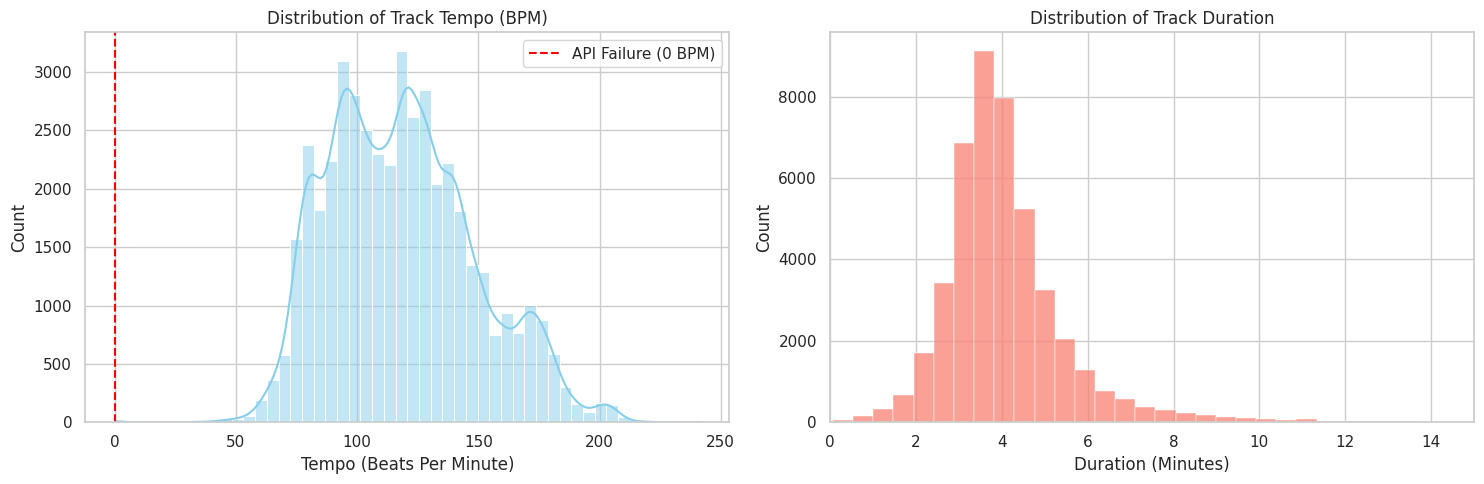

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Convert milliseconds to minutes for readability
df_final = df_final.with_columns(
    duration_mins = pl.col('duration_ms') / 60000
)
sns.set_theme(style="whitegrid")

# Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Tempo
sns.histplot(df_final['tempo'], bins=50, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribution of Track Tempo (BPM)')
axes[0].set_xlabel('Tempo (Beats Per Minute)')
axes[0].axvline(x=0, color='red', linestyle='--', label='API Failure (0 BPM)')
axes[0].legend()

# Plot 2: Duration
sns.histplot(df_final['duration_mins'], bins=100, ax=axes[1], color='salmon')
axes[1].set_title('Distribution of Track Duration')
axes[1].set_xlabel('Duration (Minutes)')
axes[1].set_xlim(0, 15) # realistic range to highlight outliers

plt.tight_layout()
plt.show()

Based on these plots, we have reasonable distributions for both track temp and duration despite there being outliers

##Feature Correlation

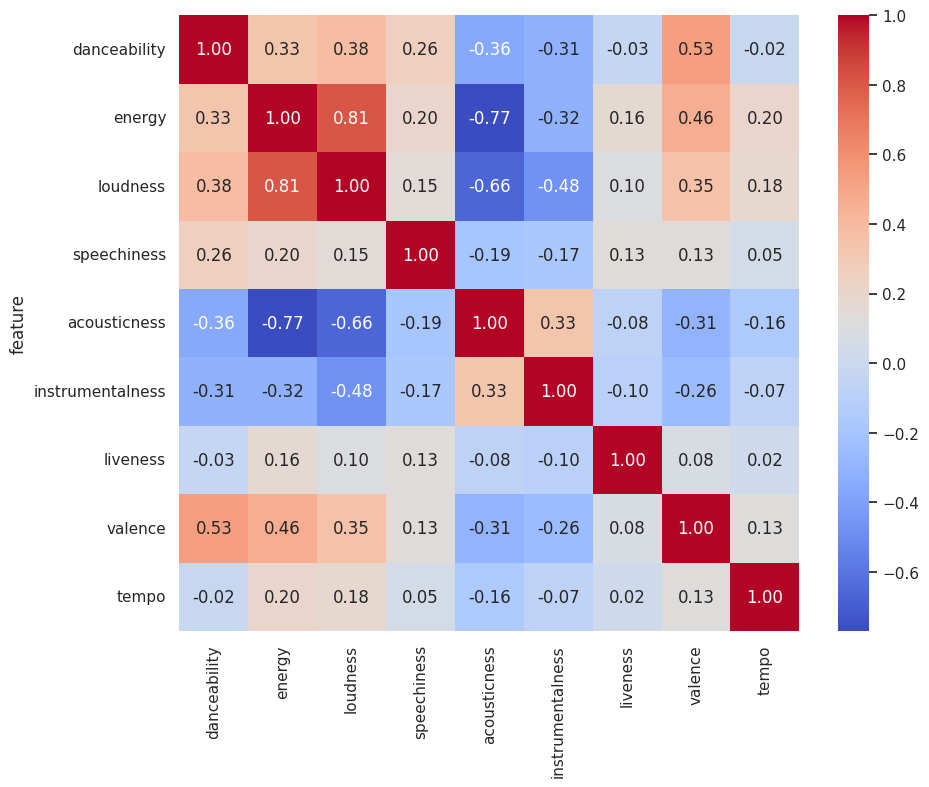

In [19]:
numerical_features = [
    'danceability', 'energy', 'loudness', 'speechiness',
    'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo'
]

# Create the correlation matrix
corr_matrix = df_final.select(numerical_features).corr()

# Manually add the labels and move them to the first column
corr_matrix = (
    corr_matrix
    .with_columns(feature=pl.Series(numerical_features))
    .select(["feature", pl.all().exclude("feature")])
)

plt.figure(figsize=(10, 8))

# Seaborn likes pandas DataFrames with indices for heatmaps
sns.heatmap(
    corr_matrix.to_pandas().set_index("feature"),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.show()

Here we can see the correlation between different audio features. Some key insights are that loudness and energy are very closely associated, which is to be expected. Furthermore, acousticness is very negatively associated with energy and loudness, which is also expected. Valence (happiness) is also related with danceability and energy, which is another sensical thing. Overrall, these features correlation makes sense.

##Variable Analysis

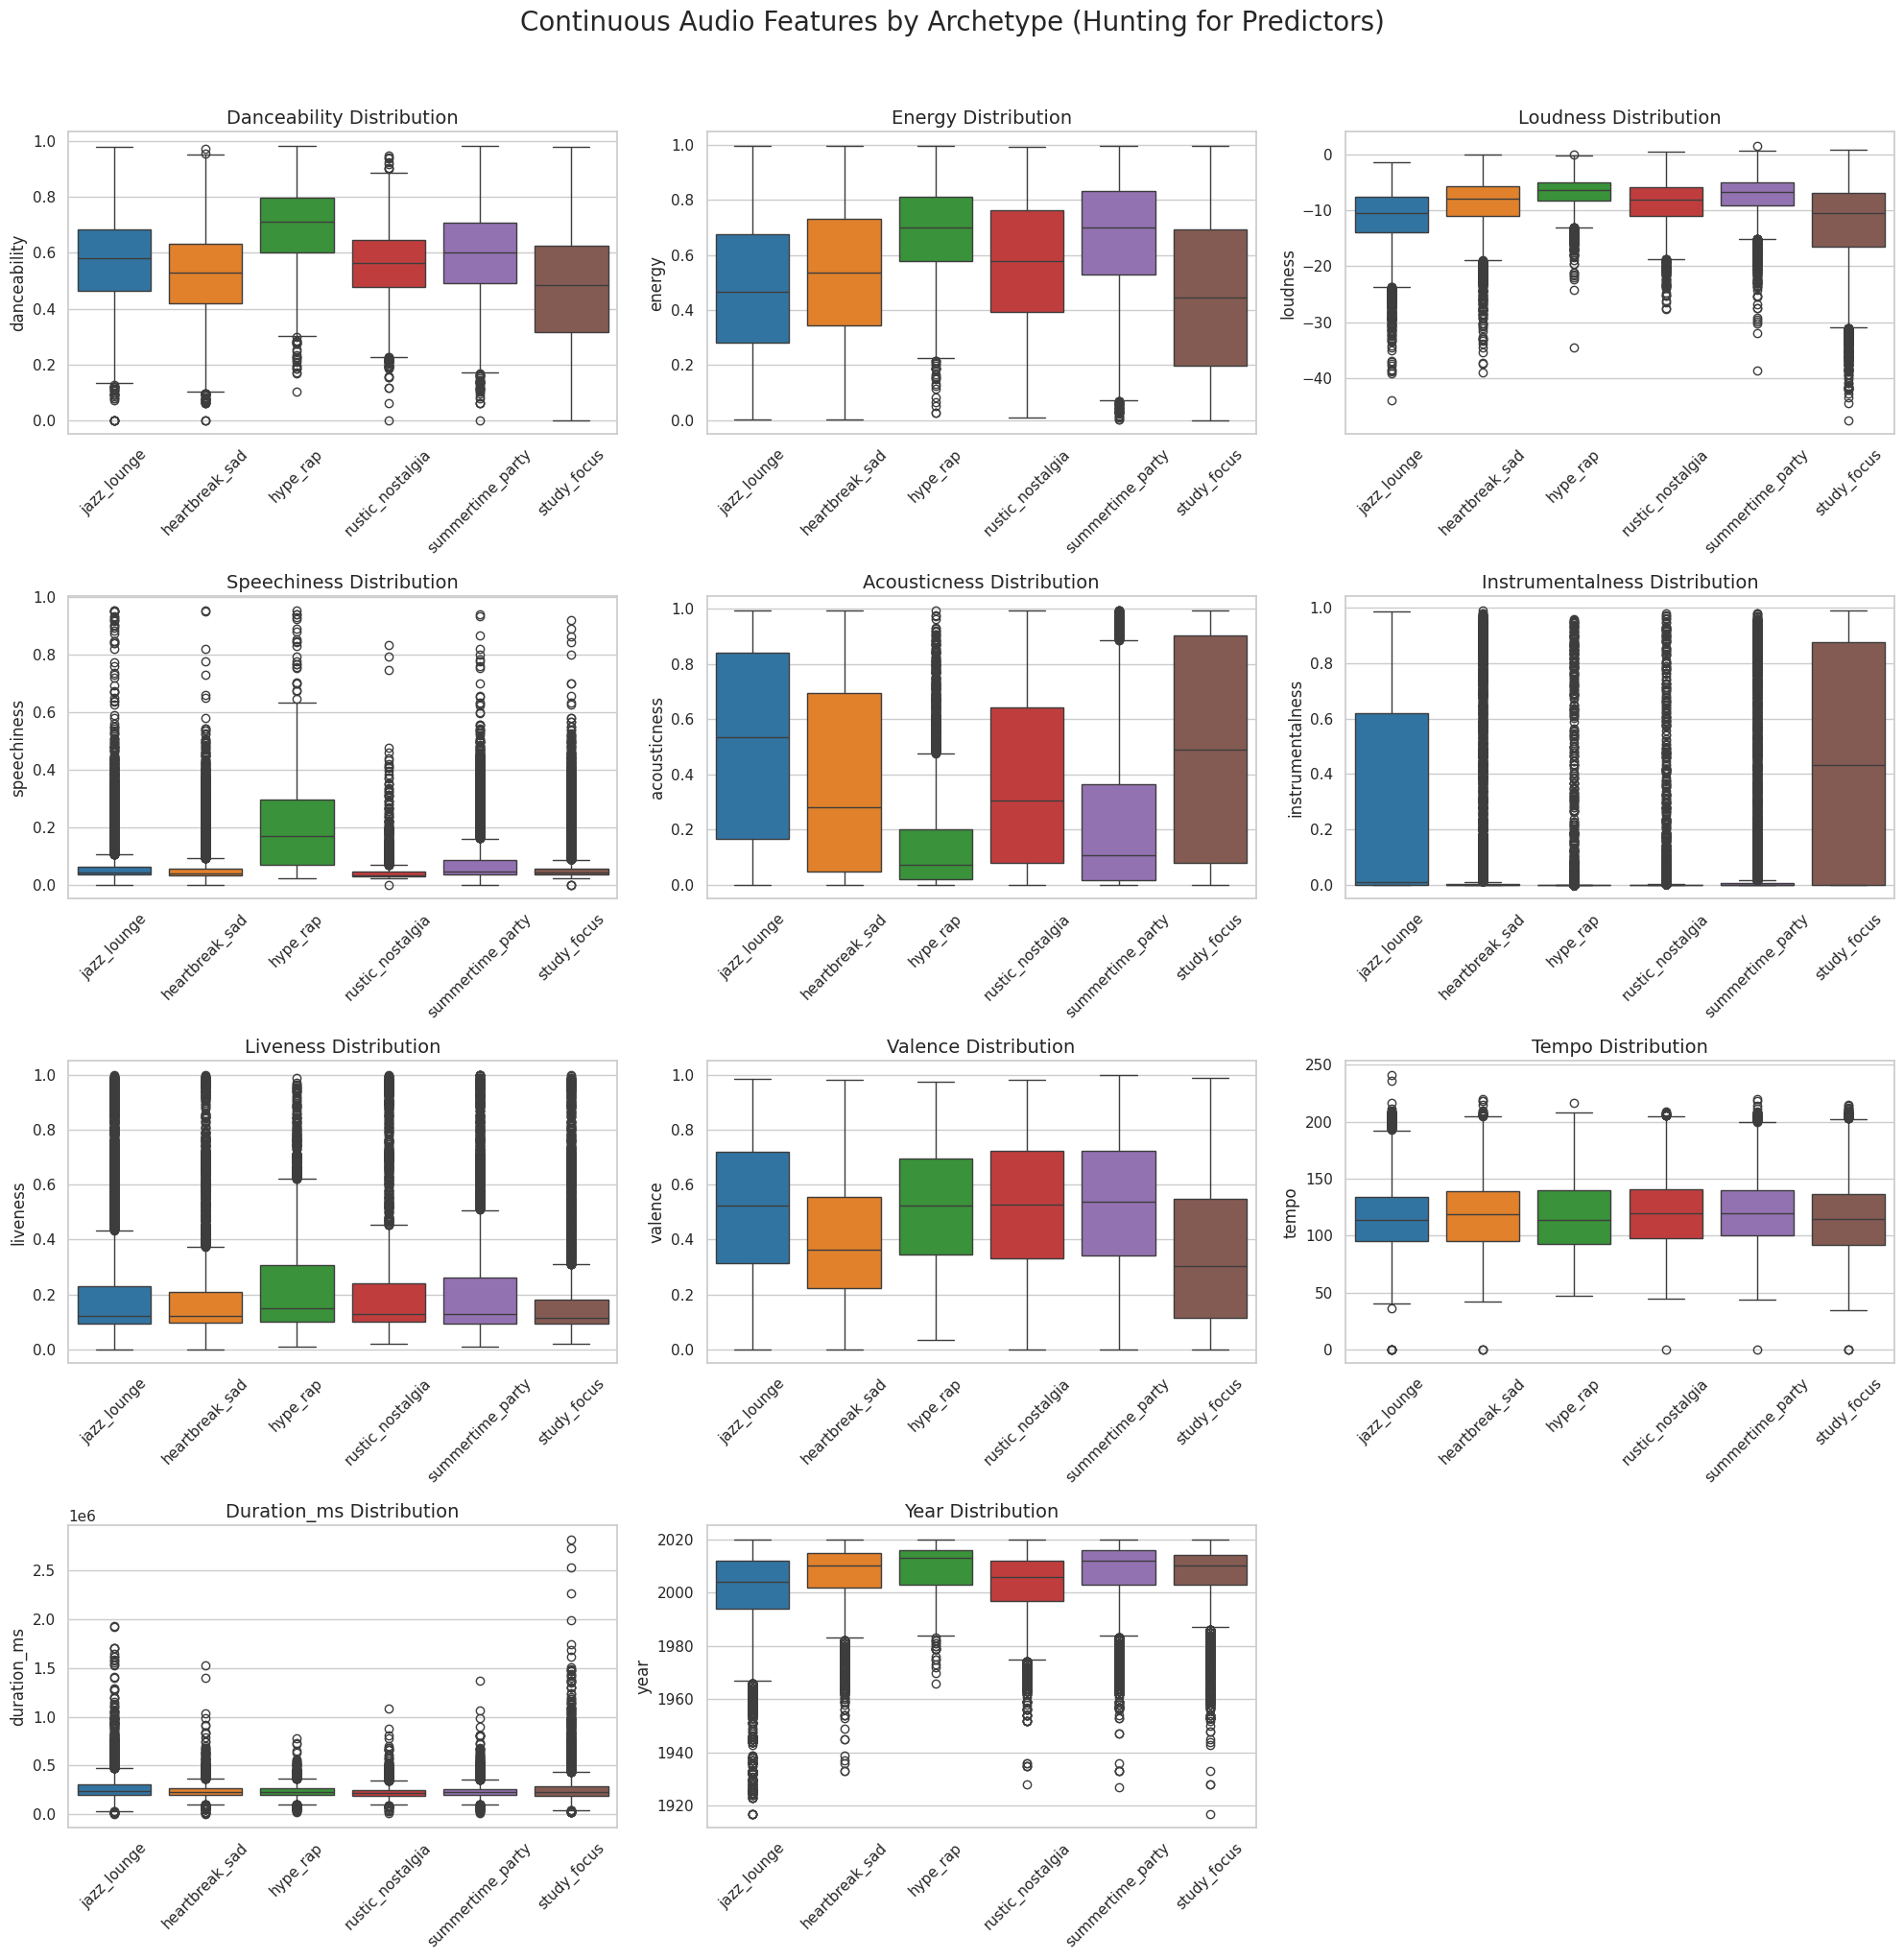

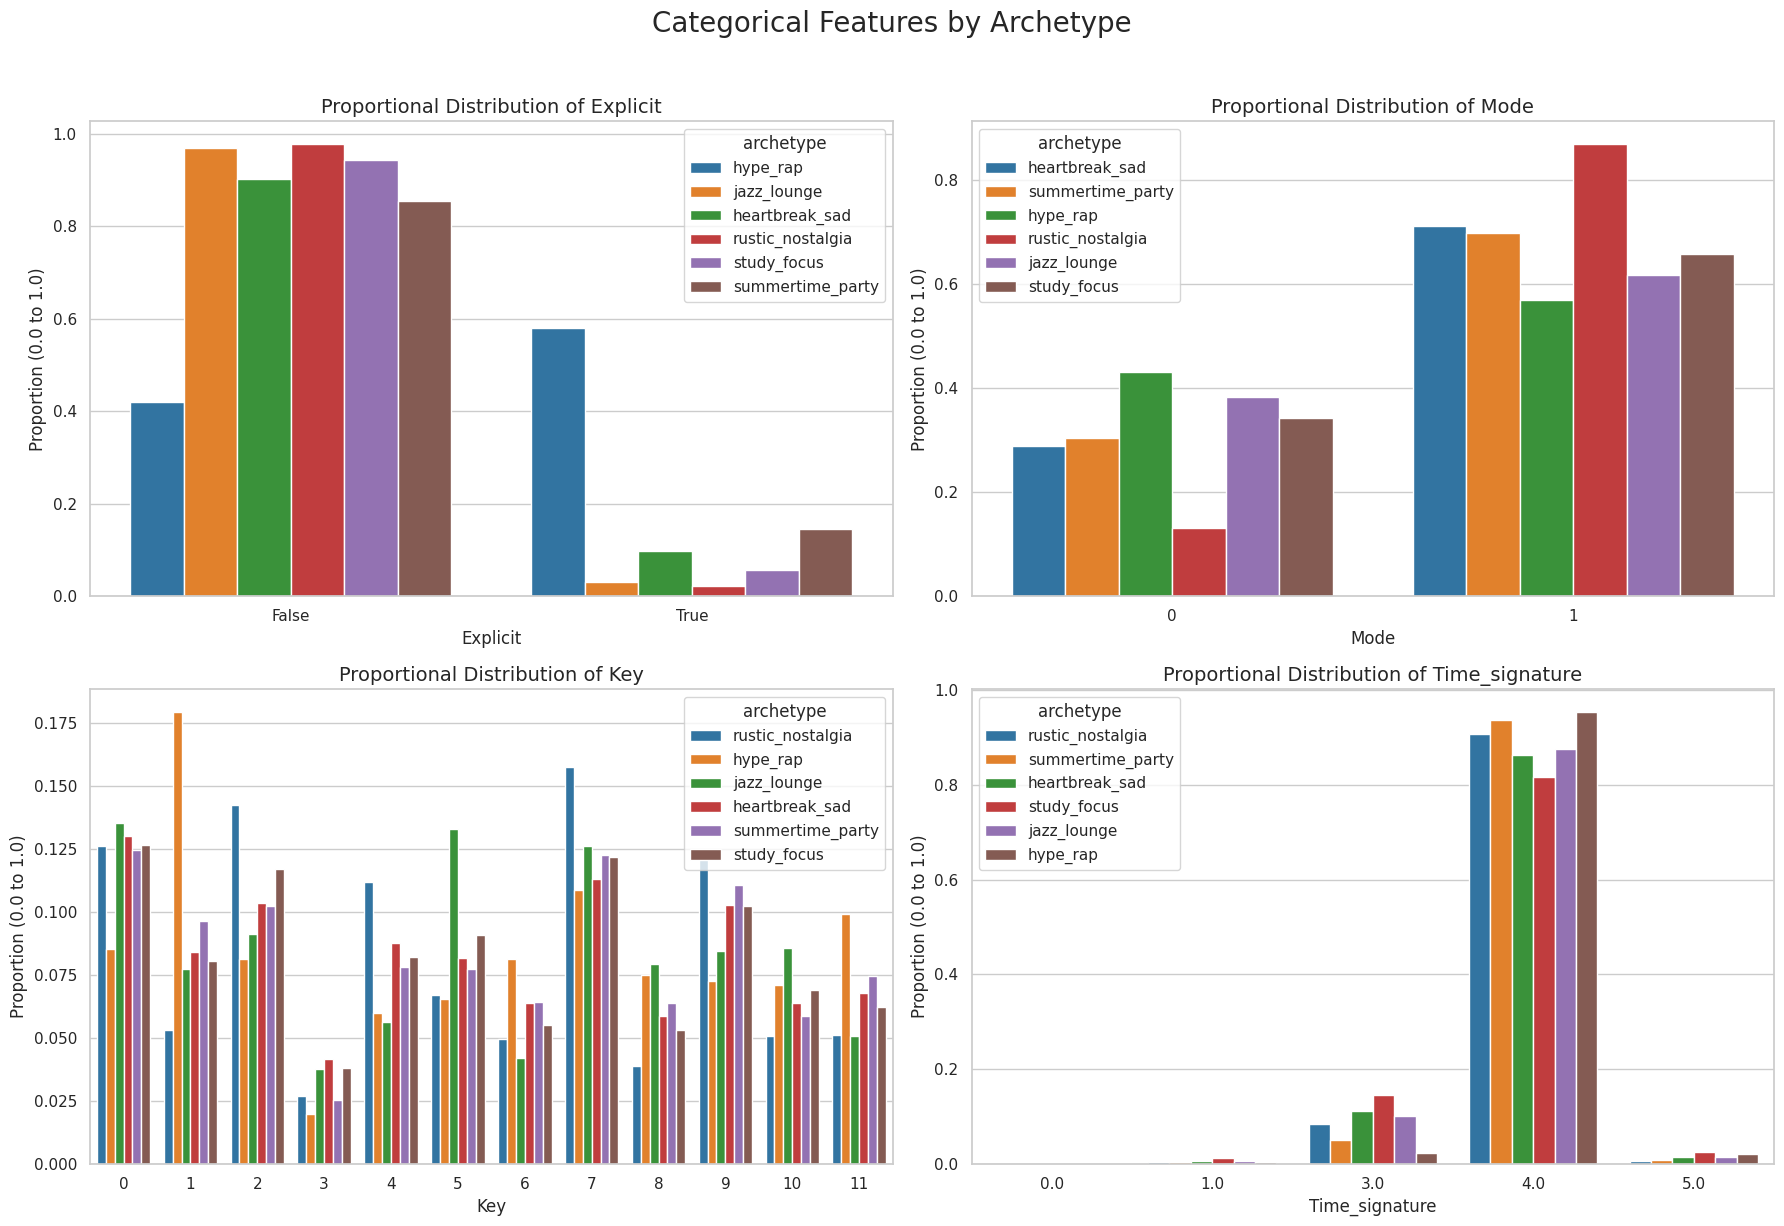

In [20]:
import math

sns.set_theme(style="whitegrid")

continuous_features = [
    'danceability', 'energy', 'loudness', 'speechiness',
    'acousticness', 'instrumentalness', 'liveness', 'valence',
    'tempo', 'duration_ms', 'year'
]

#Continuous Feature Box Plots
n_cols = 3
n_rows = math.ceil(len(continuous_features) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 5))
fig.suptitle('Continuous Audio Features by Archetype (Hunting for Predictors)', fontsize=20, y=1.02)
axes = axes.flatten()

# We convert df_final to pandas temporarily just for plotting compatibility
df_plot_cont = df_final.to_pandas()

for i, feature in enumerate(continuous_features):
    sns.boxplot(
        data=df_plot_cont,
        x='archetype',
        y=feature,
        ax=axes[i],
        palette="tab10",
        hue='archetype',
        legend=False
    )
    axes[i].set_title(f'{feature.capitalize()} Distribution', fontsize=14)
    axes[i].set_xlabel('')
    axes[i].set_ylabel(feature)
    axes[i].tick_params(axis='x', rotation=45)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


#Categorical Features Bar Plots
categorical_features = ['explicit', 'mode', 'key', 'time_signature']

fig_cat, axes_cat = plt.subplots(2, 2, figsize=(18, 12))
fig_cat.suptitle('Categorical Features by Archetype', fontsize=20, y=1.02)
axes_cat = axes_cat.flatten()

for i, feature in enumerate(categorical_features):

    prop_df = (
        df_final.group_by(['archetype', feature])
        .len()
        .with_columns(
            proportion=pl.col('len') / pl.col('len').sum().over('archetype')
        )
    )

    sns.barplot(
        data=prop_df.to_pandas(),
        x=feature,
        y='proportion',
        hue='archetype',
        ax=axes_cat[i],
        palette="tab10"
    )

    axes_cat[i].set_title(f'Proportional Distribution of {feature.capitalize()}', fontsize=14)
    axes_cat[i].set_xlabel(feature.capitalize())
    axes_cat[i].set_ylabel('Proportion (0.0 to 1.0)')

plt.tight_layout()
plt.show()

#Lyric Dataset join and NLP Analysis

###Imports and Config

In [21]:
!pip install kagglehub rapidfuzz vaderSentiment sentence-transformers transformers torch --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 30.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 7.4 MB/s eta 0:00:00


In [22]:
import os
import re
import math
import glob
import json
import time
import numpy as np
import pandas as pd
import torch

from google.colab import drive
from rapidfuzz import fuzz, process
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from sentence_transformers import SentenceTransformer, util
from transformers import pipeline
import kagglehub

#Mount Drive
drive.mount('/content/drive')

#config
INPUT_CSV = "track_info.csv"
DRIVE_OUTPUT_DIR = "/content/drive/MyDrive/CIS_2450_Final_Project/lyrics_pipeline"
FUZZY_THRESHOLD = 85 #minimum match score (0-100)

#device
DEVICE = 0 if torch.cuda.is_available() else -1
print(f"Using device: {'GPU' if DEVICE == 0 else 'CPU'}")

# Archetype seed phrases
ARCHETYPE_SEEDS = {
    "study_focus":       "instrumental focus concentration studying ambient work productivity calm",
    "heartbreak_sad":    "heartbreak sad crying lonely missing someone loss pain longing",
    "summertime_party":  "summer beach party fun sun vacation dancing happy carefree",
    "rustic_nostalgia":  "country folk home memories family roots small town acoustic",
    "jazz_lounge":       "jazz lounge smooth blues soul piano saxophone evening classy",
    "hype_rap":          "rap hiphop trap hype energy grind hustle bass aggressive",
}

os.makedirs(DRIVE_OUTPUT_DIR, exist_ok=True)
print("Config ready.")

Mounted at /content/drive
Using device: CPU
Config ready.


###Download Kaggle Genius Lyrics Dataset

In [23]:
print("Downloading Kaggle dataset...")
path = kagglehub.dataset_download("carlosgdcj/genius-song-lyrics-with-language-information")
kaggle_files = glob.glob(os.path.join(path, "*.csv"))
KAGGLE_CSV = kaggle_files[0]
print(f"CSV path: {KAGGLE_CSV}")

100%|██████████| 3.04G/3.04G [01:07<00:00, 48.7MB/s]

Extracting files...


CSV path: /root/.cache/kagglehub/datasets/carlosgdcj/genius-song-lyrics-with-language-information/versions/1/song_lyrics.csv


###Helper Functions

In [25]:
def normalize(text: str) -> str:
    """Lowercase, strip featured artist suffixes, remove punctuation.
    Applied to both datasets before fuzzy matching.
    """
    if not isinstance(text, str):
        return ""
    text = text.lower().strip()
    # Remove feat/ft suffixes common in track names
    text = re.sub(r"\s*[\(\[]?(feat\.?|ft\.?|featuring|with)\s+.*?[\)\]]?$", "", text)
    # Remove content in parentheses entirely (e.g. "Remastered 2011")
    text = re.sub(r"[\(\[].*?[\)\]]", "", text)
    # Remove punctuation except spaces
    text = re.sub(r"[^\w\s]", "", text)
    # Collapse whitespace
    text = re.sub(r"\s+", " ", text).strip()
    return text


def clean_lyrics(raw: str) -> str:
    """Strip section headers and normalize whitespace."""
    if not isinstance(raw, str):
        return ""
    raw = re.sub(r"\[.*?\]", "", raw)
    raw = re.sub(r"\n{3,}", "\n\n", raw)
    return raw.strip()

###Filter for Rows matching Artist + Title

In [26]:
df = pd.read_csv(INPUT_CSV)
df["_norm_track"]  = df["track_name"].apply(normalize)
df["_norm_artist"] = df["artist_name"].apply(normalize)

#artist set
my_artists = set(df["_norm_artist"].unique())
my_artist_tokens = set(
    tok for artist in my_artists
    for tok in artist.split()
    if len(tok) > 3
)

print(f"Unique artists in my dataset: {len(my_artists):,}")

#stream Kaggle CSV in chunks & keep only plausible matches
CHUNK_SIZE  = 100_000
kept_rows   = []
total_read  = 0
total_kept  = 0

print("Streaming Kaggle CSV and filtering...")

for chunk in pd.read_csv(
    KAGGLE_CSV,
    usecols=["title", "artist", "lyrics", "language", "tag", "views"],
    dtype=str,
    on_bad_lines="skip",
    chunksize=CHUNK_SIZE,
):
    total_read += len(chunk)

    #Normalize
    chunk["_norm_title"] = chunk["title"].apply(normalize)
    chunk["_norm_artist"] = chunk["artist"].apply(normalize)
    chunk["lyrics"] = chunk["lyrics"].apply(clean_lyrics)

    def artist_is_plausible(norm_artist: str) -> bool:
        return norm_artist in my_artists

    mask = chunk["_norm_artist"].apply(artist_is_plausible)
    filtered = chunk[mask].copy()

    kept_rows.append(filtered)
    total_kept += len(filtered)

    if (total_read // CHUNK_SIZE) % 5 == 0:
        print(f"Read {total_read:,} rows | kept {total_kept:,}"
              f"({total_kept/total_read*100:.1f}%)")

print(f"\nTotal read: {total_read:,} | Total kept: {total_kept:,}")

#combine and deduplicate
lyrics_df = pd.concat(kept_rows, ignore_index=True).drop_duplicates(
    subset=["_norm_artist", "_norm_title"]
)
print(f"Deduplicated lyrics index: {lyrics_df.shape}")

#rebuild artist groups for fuzzy matching
artist_groups = lyrics_df.groupby("_norm_artist")
kaggle_artists = set(lyrics_df["_norm_artist"].unique())
print(f"Unique artists in filtered: {len(kaggle_artists):,}")
print("\nLanguage distribution:")
print(lyrics_df["language"].value_counts().head(10))

Unique artists in my dataset: 6,348
Streaming Kaggle CSV and filtering...
Read 5,093 rows | kept 2,251(44.2%)
Read 10,594 rows | kept 4,331(40.9%)
Read 16,064 rows | kept 6,215(38.7%)
Read 21,590 rows | kept 7,890(36.5%)
Read 27,007 rows | kept 9,330(34.5%)
Read 32,581 rows | kept 11,248(34.5%)
Read 38,119 rows | kept 13,200(34.6%)
Read 43,619 rows | kept 15,421(35.4%)
Read 49,399 rows | kept 17,386(35.2%)
Read 55,894 rows | kept 18,813(33.7%)
Read 62,444 rows | kept 20,123(32.2%)
Read 69,326 rows | kept 21,523(31.0%)
Read 76,179 rows | kept 22,960(30.1%)
Read 82,497 rows | kept 24,026(29.1%)
Read 87,212 rows | kept 24,733(28.4%)
Read 92,924 rows | kept 25,674(27.6%)
Read 98,263 rows | kept 26,497(27.0%)
Read 500,766 rows | kept 99,021(19.8%)
Read 515,554 rows | kept 101,654(19.7%)
Read 529,600 rows | kept 103,962(19.6%)
Read 544,371 rows | kept 106,759(19.6%)
Read 559,319 rows | kept 109,980(19.7%)
Read 574,887 rows | kept 112,525(19.6%)
Read 590,299 rows | kept 115,044(19.5%)
Read 1,

In [1]:
# normalize datasets
print("Normalizing track/artist names...")
df["_norm_track"] = df["track_name"].apply(normalize)
df["_norm_artist"] = df["artist_name"].apply(normalize)

lyrics_df["_norm_title"] = lyrics_df["title"].apply(normalize)
lyrics_df["_norm_artist"] = lyrics_df["artist"].apply(normalize)
lyrics_df["lyrics"] = lyrics_df["lyrics"].apply(clean_lyrics)

artist_groups = lyrics_df.groupby("_norm_artist")
kaggle_artists = set(lyrics_df["_norm_artist"].unique())
print(f"Unique artists in Kaggle dataset: {len(kaggle_artists):,}")

NameError: name 'df' is not defined

###Fuzzy Matching Helper

In [ ]:
def fuzzy_match_row(norm_track: str, norm_artist: str) -> pd.Series | None:
    """
    For a given (track, artist), find the best matching row in lyrics_df.
    Strat:
      1. Exact artist match: fuzzy match on title within that artist's tracks
      2. Fuzzy artist match: fuzzy match on title within best artist match
      3. No match: return None
    """
    #exact artist match
    if norm_artist in artist_groups.groups:
        candidates = artist_groups.get_group(norm_artist)
        titles = candidates["_norm_title"].tolist()
        result = process.extractOne(
            norm_track, titles, scorer=fuzz.token_sort_ratio
        )
        if result and result[1] >= FUZZY_THRESHOLD:
            idx = titles.index(result[0])
            return candidates.iloc[idx]

    #fuzzy artist match
    artist_match = process.extractOne(
        norm_artist, list(kaggle_artists), scorer=fuzz.token_sort_ratio
    )
    if artist_match and artist_match[1] >= FUZZY_THRESHOLD:
        matched_artist = artist_match[0]
        candidates = artist_groups.get_group(matched_artist)
        titles = candidates["_norm_title"].tolist()
        result = process.extractOne(
            norm_track, titles, scorer=fuzz.token_sort_ratio
        )
        if result and result[1] >= FUZZY_THRESHOLD:
            idx = titles.index(result[0])
            return candidates.iloc[idx]

    return None

###Load VADER, j-hartmannm, and sentence transformer

In [ ]:
print("Loading VADER...")
vader = SentimentIntensityAnalyzer()

print("Loading emotion model (j-hartmann)...")
emotion_pipe = pipeline(
    "text-classification",
    model="j-hartmann/emotion-english-distilroberta-base",
    top_k=None,
    device=DEVICE,
    truncation=True,
    max_length=512,
)

print("Loading sentence transformer...")
embedder = SentenceTransformer("all-MiniLM-L6-v2")
seed_embeddings = {
    arch: embedder.encode(phrase, convert_to_tensor=True)
    for arch, phrase in ARCHETYPE_SEEDS.items()
}
print("All models ready.")

Loading VADER...
Loading emotion model (j-hartmann)...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/329M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

...

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

Loading sentence transformer...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


All models ready.


###Helpers for NLP analysis

In [ ]:
def words_per_second(lyrics: str, duration_ms: int) -> float | None:
    if not lyrics or duration_ms <= 0:
        return None
    return round(len(lyrics.split()) / (duration_ms / 1000.0), 4)


def vader_features(lyrics: str) -> dict:
    scores = vader.polarity_scores(lyrics)
    return {
        "lyric_sentiment_pos":  scores["pos"],
        "lyric_sentiment_neg":  scores["neg"],
        "lyric_sentiment_neu":  scores["neu"],
        "lyric_compound_score": scores["compound"],
    }


def emotion_features(lyrics: str) -> dict:
    text = lyrics[:2000]
    try:
        results = emotion_pipe(text)[0]
        scores  = {r["label"].lower(): round(r["score"], 4) for r in results}
        return {
            "dominant_emotion":       max(scores, key=scores.get),
            "emotion_score_anger":    scores.get("anger",    0.0),
            "emotion_score_disgust":  scores.get("disgust",  0.0),
            "emotion_score_fear":     scores.get("fear",     0.0),
            "emotion_score_joy":      scores.get("joy",      0.0),
            "emotion_score_neutral":  scores.get("neutral",  0.0),
            "emotion_score_sadness":  scores.get("sadness",  0.0),
            "emotion_score_surprise": scores.get("surprise", 0.0),
        }
    except Exception as e:
        print(f"  [WARN] Emotion model error: {e}")
        return {k: None for k in [
            "dominant_emotion", "emotion_score_anger", "emotion_score_disgust",
            "emotion_score_fear", "emotion_score_joy", "emotion_score_neutral",
            "emotion_score_sadness", "emotion_score_surprise"
        ]}


def archetype_similarity_features(lyrics: str) -> dict:
    lyric_emb = embedder.encode(lyrics[:1000], convert_to_tensor=True)
    return {
        f"lyric_arch_sim_{arch}": round(
            util.cos_sim(lyric_emb, seed_emb).item(), 4
        )
        for arch, seed_emb in seed_embeddings.items()
    }


def null_row() -> dict:
    return {
        "has_lyrics":              0,
        "lyrics_language":         None,
        "genius_tag":              None,
        "genius_views":            None,
        "words_per_second":        None,
        "lyric_sentiment_pos":     None,
        "lyric_sentiment_neg":     None,
        "lyric_sentiment_neu":     None,
        "lyric_compound_score":    None,
        "dominant_emotion":        None,
        "emotion_score_anger":     None,
        "emotion_score_disgust":   None,
        "emotion_score_fear":      None,
        "emotion_score_joy":       None,
        "emotion_score_neutral":   None,
        "emotion_score_sadness":   None,
        "emotion_score_surprise":  None,
        **{f"lyric_arch_sim_{a}": None for a in ARCHETYPE_SEEDS},
    }

###Test for functionality

In [ ]:
test_df = df.sample(10, random_state=42).reset_index(drop=True)
print("test on 10 songs...\n")

for _, row in test_df.iterrows():
    match = fuzzy_match_row(row["_norm_track"], row["_norm_artist"])

    if match is None:
        print(f"NO MATCH | {row['artist_name']} — {row['track_name']}")
    else:
        lyrics  = match["lyrics"] if isinstance(match["lyrics"], str) else ""
        lang    = match.get("language", "unknown")
        print(f"MATCHED  | {row['artist_name']} — {row['track_name']}")
        print(f"    Kaggle: {match['artist']} — {match['title']}")
        print(f"    language: {lang} | words: {len(lyrics.split())}")
        if lyrics and lang == "en":
            v = vader_features(lyrics)
            e = emotion_features(lyrics)
            print(f"    compound: {v['lyric_compound_score']} | "
                  f"dominant: {e['dominant_emotion']}")
        print()

Running smoke test on 10 songs...

✗ NO MATCH | CNCO — Reggaetón Lento (Remix)
✗ NO MATCH | Ramsey Lewis Trio — Wade In The Water
✓ MATCHED  | Julie Bergan — Blackout
    → Kaggle: Julie Bergan — Blackout
    language: en | words: 249
    compound: -0.1025 | dominant: anger

✗ NO MATCH | José Feliciano — Feliz Navidad
✓ MATCHED  | Toby Keith — Kissin' In The Rain
    → Kaggle: Toby Keith — Kissin In The Rain
    language: en | words: 292
    compound: 0.9904 | dominant: anger

✓ MATCHED  | A$AP Rocky — Goldie
    → Kaggle: A$AP Rocky — Goldie
    language: en | words: 583
    compound: -0.9964 | dominant: disgust

✗ NO MATCH | Happy Baby Lullaby Collection — And I Love Her
✓ MATCHED  | Pentatonix — If I Ever Fall In Love
    → Kaggle: Pentatonix — If I Ever Fall In Love
    language: en | words: 308
    compound: 0.9995 | dominant: neutral

✗ NO MATCH | Vitamin String Quartet — Rebellion (Lies)
✗ NO MATCH | Hammock — Dust Is the Devil's Snow


###Run all NLP in batches

In [ ]:
print(f"Processing {len(lyrics_df):,} rows...\n")

all_results = []
found_count = 0

for i, (_, row) in enumerate(lyrics_df.iterrows()):
    track_id    = row["spotify_track_id"]
    duration_ms = row.get("duration_ms", 0)

    # Fuzzy match against Kaggle dataset
    match = fuzzy_match_row(row["_norm_track"], row["_norm_artist"])

    if match is None:
        result = {"spotify_track_id": track_id, **null_row()}
    else:
        lyrics = match["lyrics"] if isinstance(match["lyrics"], str) else ""
        lang   = match.get("language", None)
        tag    = match.get("tag", None)
        views  = match.get("views", None)

        if not lyrics:
            result = {"spotify_track_id": track_id, **null_row()}
        else:
            feats = {
                "spotify_track_id": track_id,
                "has_lyrics":       1,
                "lyrics_language":  lang,
                "genius_tag":       tag,
                "genius_views":     views,
                "words_per_second": words_per_second(lyrics, duration_ms),
            }
            feats.update(vader_features(lyrics))
            # Only run emotion model on English lyrics for accuracy
            if lang == "en":
                feats.update(emotion_features(lyrics))
            else:
                feats.update({k: None for k in [
                    "dominant_emotion", "emotion_score_anger",
                    "emotion_score_disgust", "emotion_score_fear",
                    "emotion_score_joy", "emotion_score_neutral",
                    "emotion_score_sadness", "emotion_score_surprise"
                ]})
            feats.update(archetype_similarity_features(lyrics))
            result = feats
            found_count += 1

    all_results.append(result)

    # Print progress every 500 rows
    if (i + 1) % 500 == 0 or (i + 1) == len(lyrics_df):
        found_pct = found_count / (i + 1) * 100
        print(f"  [{i + 1}/{len(lyrics_df)}] "
              f"match rate: {found_pct:.1f}% | "
              f"last: '{row['track_name'][:35]}'")

combined = pd.DataFrame(all_results)

print(f"Combined shape:  {combined.shape}")
print(f"has_lyrics rate: {combined['has_lyrics'].mean():.1%}")
print(f"\nLanguage distribution of matched tracks:")
print(combined["lyrics_language"].value_counts().head(10))
print(f"\nDominant emotion distribution:")
print(combined["dominant_emotion"].value_counts())

#Save to CSV
final_path = os.path.join(DRIVE_OUTPUT_DIR, "lyrics_features_FINAL.csv")
combined.to_csv(final_path, index=False)
print(f"\nFinal file saved: {final_path}")

Processing 45,164 rows in 10 batch(es) of 5000.

━━━ Batch 1/10  (rows 0–4999) ━━━


You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


  [500/5000] match rate: 80.6% | last: 'Rooster'
  [1000/5000] match rate: 79.7% | last: 'Love On Top'
  [1500/5000] match rate: 79.4% | last: 'I Am'
  [2000/5000] match rate: 80.0% | last: 'California - Tchad Blake Mix'
  [2500/5000] match rate: 80.4% | last: 'A Most Peculiar Man'
  [3000/5000] match rate: 80.6% | last: 'God Made Dirt'
  [3500/5000] match rate: 80.6% | last: 'I Still Believe - English Version'
  [4000/5000] match rate: 80.0% | last: 'I Can't Wake Up'
  [4500/5000] match rate: 80.0% | last: 'Pocket Full of Stones'
  [5000/5000] match rate: 80.1% | last: 'FUK UR MGMT'
  ✓ Saved batch 1 → /content/drive/MyDrive/lyrics_pipeline/lyrics_features_batch_001.csv

━━━ Batch 2/10  (rows 5000–9999) ━━━
  [500/5000] match rate: 80.8% | last: 'Animus Vox'
  [1000/5000] match rate: 80.6% | last: 'Tamale'
  [1500/5000] match rate: 80.7% | last: 'Tourist'
  [2000/5000] match rate: 75.7% | last: 'Khayaal'
  [2500/5000] match rate: 69.4% | last: 'Come Home To Me'
  [3000/5000] match rat

###Join with track_info to get Full Dataset

In [ ]:
lyric_features = pd.read_csv(final_path)
df_enriched    = df.merge(lyric_features, on="spotify_track_id", how="left")
df_enriched["has_lyrics"] = df_enriched["has_lyrics"].fillna(0).astype(int)

# Drop internal normalization columns
df_enriched.drop(columns=["_norm_track", "_norm_artist"], inplace=True, errors="ignore")

print(f"Original shape: {df.shape}")
print(f"Enriched shape: {df_enriched.shape}")
print(f"\nNew columns added:")
new_cols = [c for c in df_enriched.columns if c not in df.columns]
for c in new_cols:
    null_pct = df_enriched[c].isna().mean() * 100
    print(f"  {c:<40} {null_pct:.1f}% null")

enriched_path = os.path.join(DRIVE_OUTPUT_DIR, "dataset_with_lyrics_FINAL.csv")
df_enriched.to_csv(enriched_path, index=False)
print(f"\nEnriched dataset saved: {enriched_path}")

Original shape:  (45164, 26)
Enriched shape:  (45164, 47)

New columns added:
  has_lyrics                               0.0% null
  lyrics_language                          35.2% null
  genius_tag                               34.4% null
  genius_views                             34.4% null
  words_per_second                         34.4% null
  lyric_sentiment_pos                      34.4% null
  lyric_sentiment_neg                      34.4% null
  lyric_sentiment_neu                      34.4% null
  lyric_compound_score                     34.4% null
  dominant_emotion                         36.4% null
  emotion_score_anger                      36.4% null
  emotion_score_disgust                    36.4% null
  emotion_score_fear                       36.4% null
  emotion_score_joy                        36.4% null
  emotion_score_neutral                    36.4% null
  emotion_score_sadness                    36.4% null
  emotion_score_surprise                   36.4% null
  lyr

#

#EDA (Lyrical Features)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from google.colab import drive
import os

drive.mount('/content/drive')

LYRICS_DIR  = "/content/drive/MyDrive/lyrics_pipeline"
LASTFM_DIR  = "/content/drive/MyDrive/lastfm_pipeline"
EDA_OUT_DIR = "/content/drive/MyDrive/eda_outputs"

os.makedirs(EDA_OUT_DIR, exist_ok=True)

#Load raw enriched dataset
df_raw = pd.read_csv(f"{LYRICS_DIR}/dataset_with_lyrics_FINAL.csv")

#Deduplicate by highest total_arch_score
df = (
    df_raw.sort_values("total_arch_score", ascending=False)
          .drop_duplicates(subset="spotify_track_id", keep="first")
          .reset_index(drop=True)
)

ARCHETYPES = sorted(df["archetype"].unique())
PALETTE    = dict(zip(ARCHETYPES, sns.color_palette("tab10", len(ARCHETYPES))))

print(f"Raw deduplicated dataset: {df.shape[0]:,} rows × {df.shape[1]} cols")
print(f"\nArchetype distribution:")
print(df["archetype"].value_counts())

df["_has_lyrics"] = df["has_lyrics"].fillna(0).astype(int)
df["_is_instrumental"] = (df["instrumentalness"] >= 0.5).astype(int)
df["_lyric_status"] = np.where(
    df["_has_lyrics"] == 1, "matched",
    np.where(df["_is_instrumental"] == 1,
             "instrumental", "unmatched_likely_lyrics")
)

print(f"\nLyric status breakdown:")
print(df["_lyric_status"].value_counts())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Raw deduplicated dataset: 32,112 rows × 47 cols

Archetype distribution:
archetype
study_focus         8105
jazz_lounge         7748
summertime_party    4692
heartbreak_sad      4489
rustic_nostalgia    3592
hype_rap            3486
Name: count, dtype: int64

Lyric status breakdown:
_lyric_status
matched                    18973
instrumental                6942
unmatched_likely_lyrics     6197
Name: count, dtype: int64


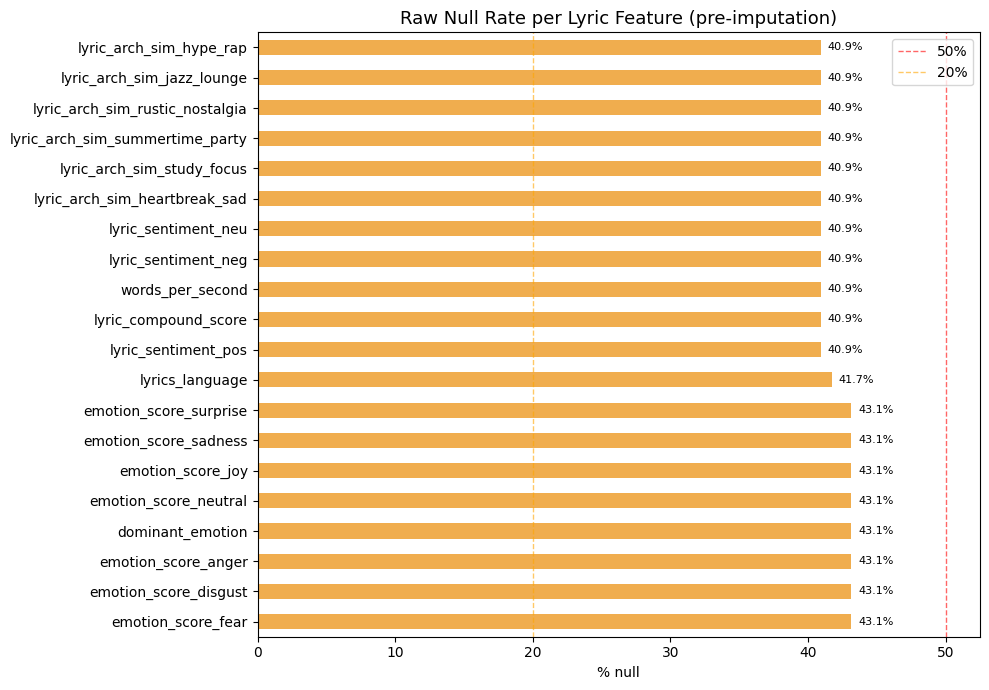


Null counts per feature:
words_per_second                   13139
lyric_compound_score               13139
lyric_sentiment_pos                13139
lyric_sentiment_neg                13139
lyric_sentiment_neu                13139
dominant_emotion                   13850
emotion_score_anger                13850
emotion_score_disgust              13850
emotion_score_fear                 13850
emotion_score_joy                  13850
emotion_score_neutral              13850
emotion_score_sadness              13850
emotion_score_surprise             13850
lyric_arch_sim_study_focus         13139
lyric_arch_sim_heartbreak_sad      13139
lyric_arch_sim_summertime_party    13139
lyric_arch_sim_rustic_nostalgia    13139
lyric_arch_sim_jazz_lounge         13139
lyric_arch_sim_hype_rap            13139
lyrics_language                    13406


In [ ]:
lyric_cols = [
    "words_per_second", "lyric_compound_score",
    "lyric_sentiment_pos", "lyric_sentiment_neg", "lyric_sentiment_neu",
    "dominant_emotion",
    "emotion_score_anger", "emotion_score_disgust", "emotion_score_fear",
    "emotion_score_joy", "emotion_score_neutral",
    "emotion_score_sadness", "emotion_score_surprise",
    "lyric_arch_sim_study_focus", "lyric_arch_sim_heartbreak_sad",
    "lyric_arch_sim_summertime_party", "lyric_arch_sim_rustic_nostalgia",
    "lyric_arch_sim_jazz_lounge", "lyric_arch_sim_hype_rap",
    "lyrics_language",
]
lyric_cols = [c for c in lyric_cols if c in df.columns]

null_pcts = df[lyric_cols].isna().mean().sort_values(ascending=False) * 100

fig, ax = plt.subplots(figsize=(10, 7))
colors  = ["#d9534f" if p > 50 else "#f0ad4e" if p > 20 else "#5cb85c"
           for p in null_pcts]
null_pcts.plot(kind="barh", ax=ax, color=colors)
ax.set_title("Raw Null Rate per Lyric Feature (pre-imputation)", fontsize=13)
ax.set_xlabel("% null")
for i, v in enumerate(null_pcts):
    ax.text(v + 0.5, i, f"{v:.1f}%", va="center", fontsize=8)
ax.legend()
plt.tight_layout()
plt.savefig(f"{EDA_OUT_DIR}/null_rates.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nNull counts per feature:")
print(df[lyric_cols].isna().sum().to_string())

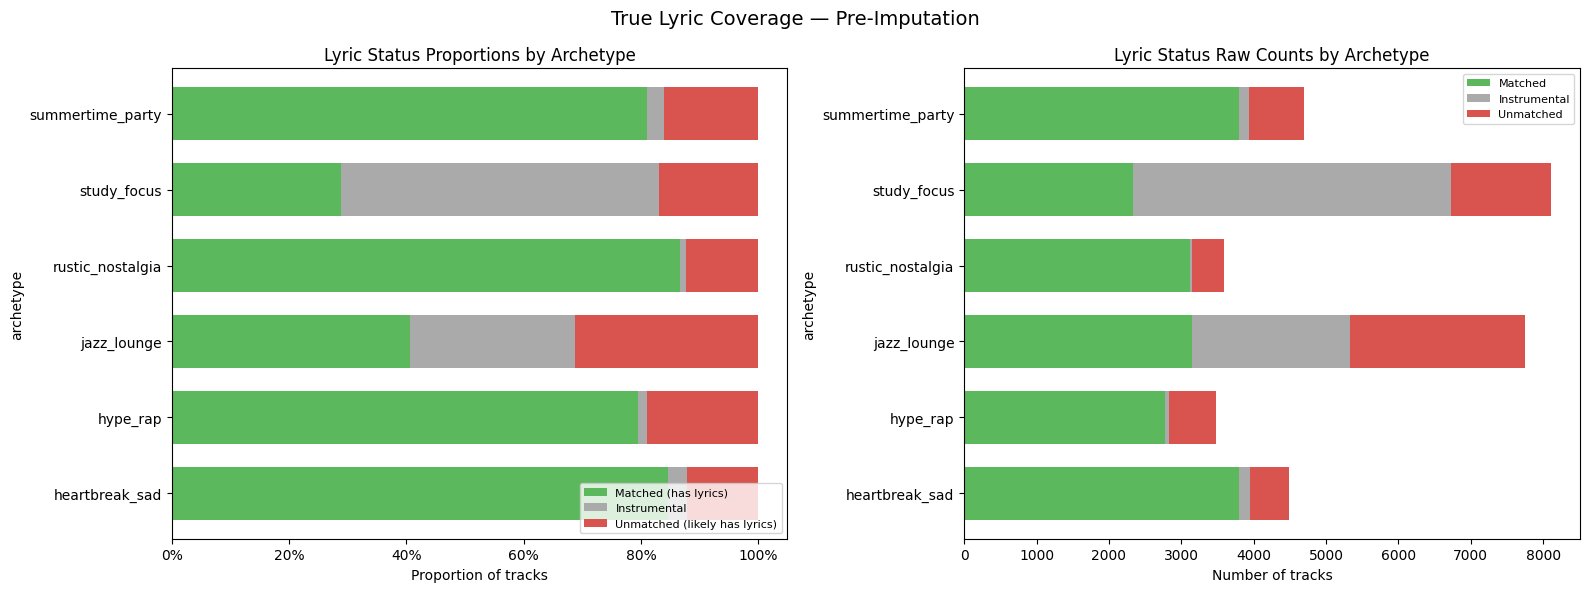


Raw counts:
_lyric_status     instrumental  matched  unmatched_likely_lyrics
archetype                                                       
heartbreak_sad             144     3801                      544
hype_rap                    51     2774                      661
jazz_lounge               2191     3141                     2416
rustic_nostalgia            31     3116                      445
study_focus               4393     2337                     1375
summertime_party           132     3804                      756

Proportions:
_lyric_status     instrumental  matched  unmatched_likely_lyrics
archetype                                                       
heartbreak_sad           0.032    0.847                    0.121
hype_rap                 0.015    0.796                    0.190
jazz_lounge              0.283    0.405                    0.312
rustic_nostalgia         0.009    0.867                    0.124
study_focus              0.542    0.288                    0.17

In [ ]:
status_counts = (
    df.groupby(["archetype", "_lyric_status"])
      .size().unstack(fill_value=0)
)
#Ensure all status columns exist
for s in ["matched", "instrumental", "unmatched_likely_lyrics"]:
    if s not in status_counts.columns:
        status_counts[s] = 0

status_props = status_counts.div(status_counts.sum(axis=1), axis=0)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

#Proportions
status_props[["matched", "instrumental", "unmatched_likely_lyrics"]].plot(
    kind="barh", stacked=True, ax=axes[0],
    color=["#5cb85c", "#aaaaaa", "#d9534f"],
    width=0.7
)
axes[0].set_title("Lyric Status Proportions by Archetype", fontsize=12)
axes[0].set_xlabel("Proportion of tracks")
axes[0].legend(["Matched (has lyrics)", "Instrumental", "Unmatched (likely has lyrics)"],
               loc="lower right", fontsize=8)
axes[0].xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

#Raw counts
status_counts[["matched", "instrumental", "unmatched_likely_lyrics"]].plot(
    kind="barh", stacked=True, ax=axes[1],
    color=["#5cb85c", "#aaaaaa", "#d9534f"],
    width=0.7
)
axes[1].set_title("Lyric Status Raw Counts by Archetype", fontsize=12)
axes[1].set_xlabel("Number of tracks")
axes[1].legend(["Matched", "Instrumental", "Unmatched"], fontsize=8)

plt.suptitle("Lyric Coverage", fontsize=14)
plt.tight_layout()
plt.savefig(f"{EDA_OUT_DIR}/lyric_status_by_archetype.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nRaw counts:")
print(status_counts)
print("\nProportions:")
print(status_props.round(3))

Matched tracks for sentiment EDA: 18,973


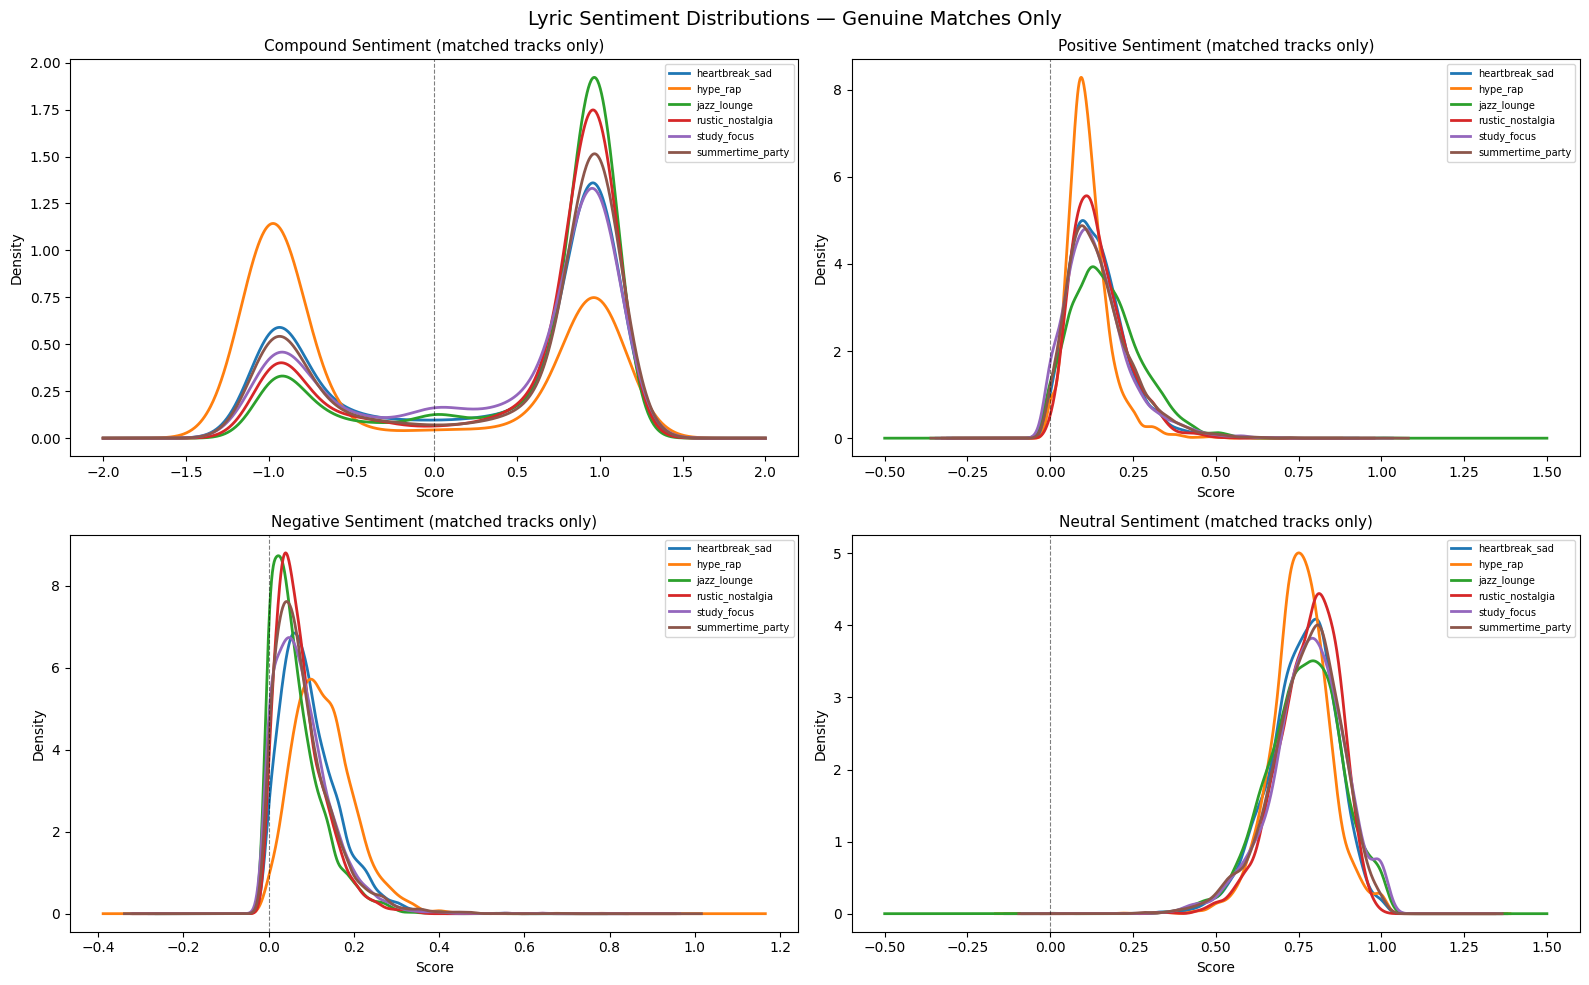

/tmp/ipykernel_2128/1580031867.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=matched, x="archetype", y="lyric_compound_score",


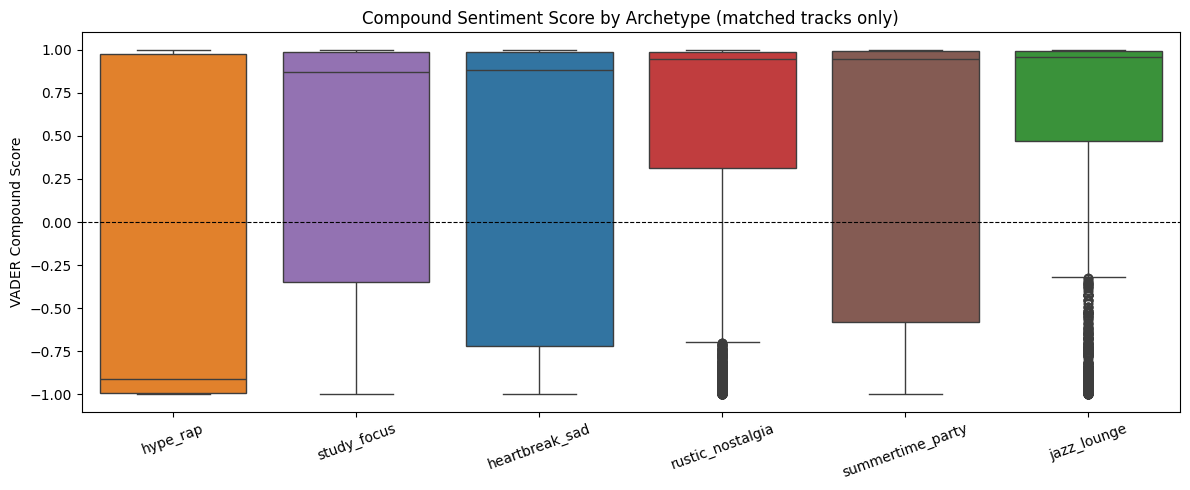

In [ ]:
matched = df[df["_lyric_status"] == "matched"].copy()
print(f"Matched tracks for sentiment EDA: {len(matched):,}")

sentiment_cols   = ["lyric_compound_score", "lyric_sentiment_pos",
                    "lyric_sentiment_neg", "lyric_sentiment_neu"]
sentiment_labels = ["Compound", "Positive", "Negative", "Neutral"]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, (col, label) in enumerate(zip(sentiment_cols, sentiment_labels)):
    ax = axes[i]
    for arch in ARCHETYPES:
        vals = matched.loc[matched["archetype"] == arch, col].dropna()
        if len(vals) > 10:
            vals.plot.kde(ax=ax, label=arch, color=PALETTE[arch], linewidth=2)
    ax.set_title(f"{label} Sentiment (matched tracks only)", fontsize=11)
    ax.set_xlabel("Score")
    ax.set_ylabel("Density")
    ax.legend(fontsize=7)
    ax.axvline(0, color="black", linestyle="--", linewidth=0.8, alpha=0.5)

plt.suptitle("Lyric Sentiment Distributions — Genuine Matches Only", fontsize=14)
plt.tight_layout()
plt.savefig(f"{EDA_OUT_DIR}/sentiment_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

#Boxplot compound score
fig, ax = plt.subplots(figsize=(12, 5))
order = (matched.groupby("archetype")["lyric_compound_score"]
                .median().sort_values().index.tolist())
sns.boxplot(data=matched, x="archetype", y="lyric_compound_score",
            order=order, palette=PALETTE, ax=ax)
ax.axhline(0, color="black", linestyle="--", linewidth=0.8)
ax.set_title("Compound Sentiment Score by Archetype (matched tracks only)", fontsize=12)
ax.set_xlabel("")
ax.set_ylabel("VADER Compound Score")
ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.savefig(f"{EDA_OUT_DIR}/compound_boxplot.png", dpi=150, bbox_inches="tight")
plt.show()

English matched tracks for emotion EDA: 18,262


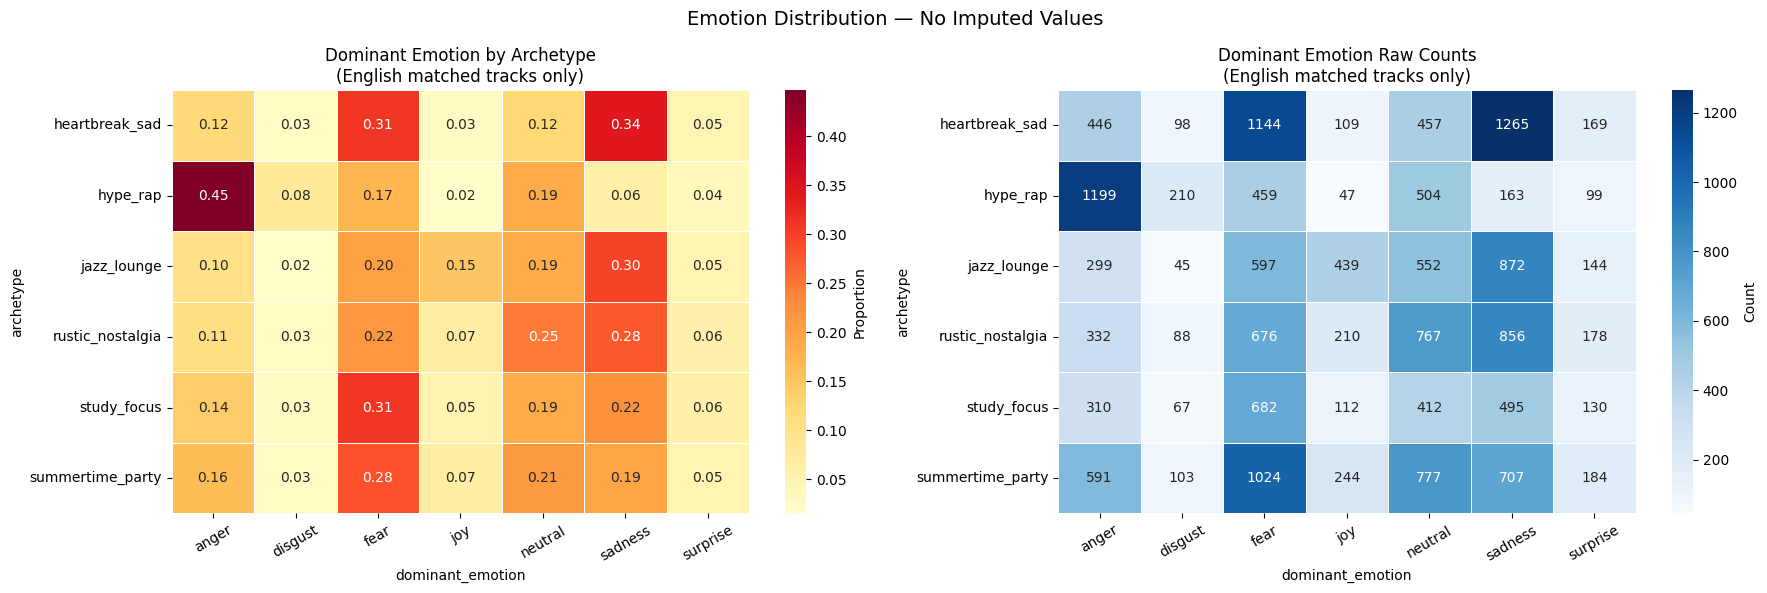

In [ ]:
if "dominant_emotion" in df.columns and "lyrics_language" in df.columns:
    eng_matched = matched[matched["lyrics_language"] == "en"].copy()
    print(f"English matched tracks for emotion EDA: {len(eng_matched):,}")

    emotion_counts = (
        eng_matched[eng_matched["dominant_emotion"].notna()]
        .groupby(["archetype", "dominant_emotion"])
        .size().unstack(fill_value=0)
    )
    emotion_props = emotion_counts.div(emotion_counts.sum(axis=1), axis=0)

    fig, axes = plt.subplots(1, 2, figsize=(18, 6))

    sns.heatmap(emotion_props, annot=True, fmt=".2f", cmap="YlOrRd",
                linewidths=0.5, ax=axes[0],
                cbar_kws={"label": "Proportion"})
    axes[0].set_title("Dominant Emotion by Archetype\n(English matched tracks only)",
                      fontsize=12)
    axes[0].tick_params(axis="x", rotation=30)

    # Also show raw counts for context
    sns.heatmap(emotion_counts, annot=True, fmt="d", cmap="Blues",
                linewidths=0.5, ax=axes[1],
                cbar_kws={"label": "Count"})
    axes[1].set_title("Dominant Emotion Raw Counts\n(English matched tracks only)",
                      fontsize=12)
    axes[1].tick_params(axis="x", rotation=30)

    plt.suptitle("Emotion Distribution — No Imputed Values", fontsize=14)
    plt.tight_layout()
    plt.savefig(f"{EDA_OUT_DIR}/emotion_heatmap.png", dpi=150, bbox_inches="tight")
    plt.show()

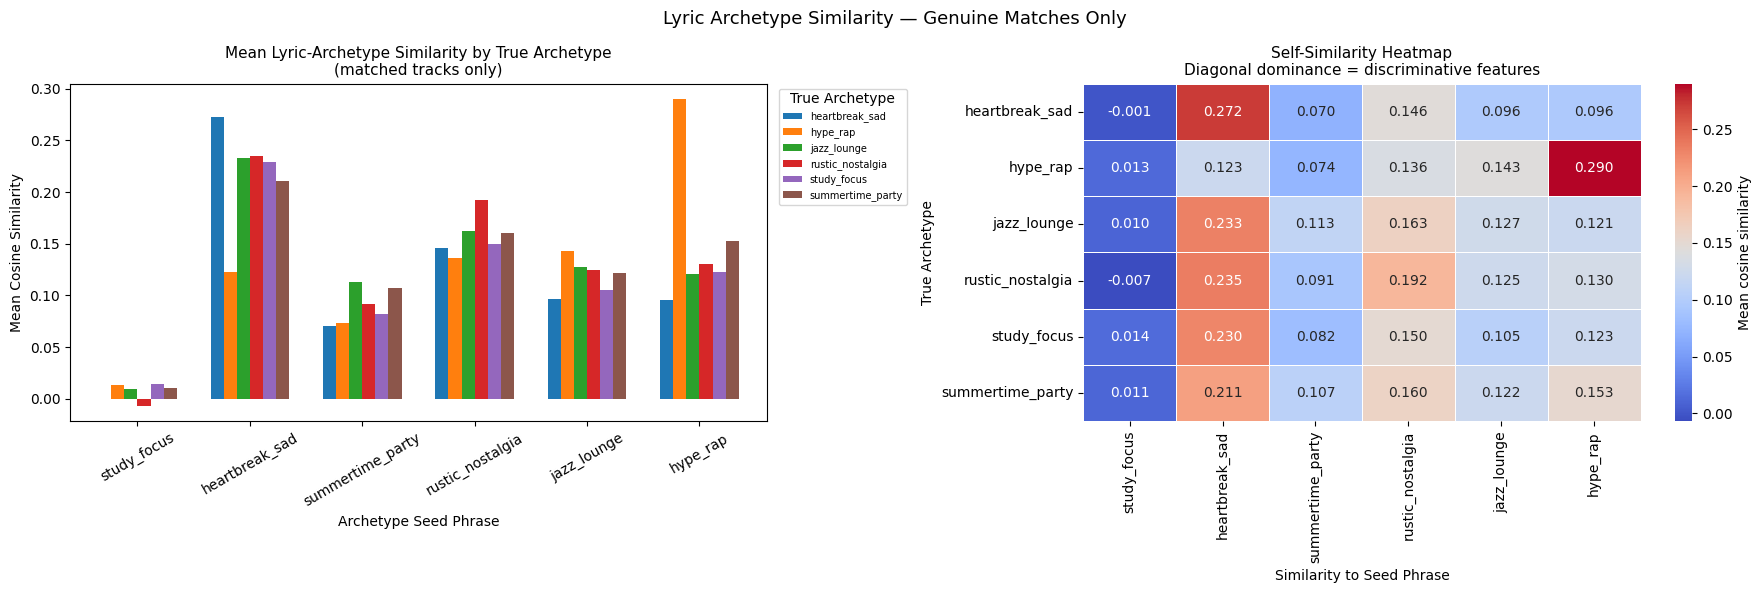


Self-similarity check (is own-archetype sim the highest?):
  heartbreak_sad            top=heartbreak_sad            ✓
  hype_rap                  top=hype_rap                  ✓
  jazz_lounge               top=heartbreak_sad            ✗
  rustic_nostalgia          top=heartbreak_sad            ✗
  study_focus               top=heartbreak_sad            ✗
  summertime_party          top=heartbreak_sad            ✗


In [ ]:
arch_sim_cols = [c for c in df.columns if c.startswith("lyric_arch_sim_")]
arch_sim_labels = [c.replace("lyric_arch_sim_", "") for c in arch_sim_cols]

if arch_sim_cols:
    sim_means = matched.groupby("archetype")[arch_sim_cols].mean()
    sim_means.columns = arch_sim_labels

    fig, axes = plt.subplots(1, 2, figsize=(18, 6))

    # Bar chart
    sim_means.T.plot(kind="bar", ax=axes[0],
                     color=[PALETTE[a] for a in sim_means.index], width=0.7)
    axes[0].set_title("Mean Lyric-Archetype Similarity by True Archetype\n"
                      "(matched tracks only)", fontsize=11)
    axes[0].set_xlabel("Archetype Seed Phrase")
    axes[0].set_ylabel("Mean Cosine Similarity")
    axes[0].tick_params(axis="x", rotation=30)
    axes[0].legend(title="True Archetype", fontsize=7,
                   bbox_to_anchor=(1.01, 1), loc="upper left")

    # Heatmap — diagonal dominance check
    sns.heatmap(sim_means, annot=True, fmt=".3f", cmap="coolwarm",
                linewidths=0.5, ax=axes[1],
                cbar_kws={"label": "Mean cosine similarity"})
    axes[1].set_title("Self-Similarity Heatmap"
                      , fontsize=11)
    axes[1].set_xlabel("Similarity to Seed Phrase")
    axes[1].set_ylabel("True Archetype")

    plt.suptitle("Lyric Archetype Similarity", fontsize=13)
    plt.tight_layout()
    plt.savefig(f"{EDA_OUT_DIR}/arch_similarity_heatmap.png", dpi=150,
                bbox_inches="tight")
    plt.show()

    # Self-similarity score: is each archetype highest on its own seed?
    print("\nSelf-similarity check (is own-archetype sim the highest?):")
    for arch in ARCHETYPES:
        if arch not in sim_means.index:
            continue
        row     = sim_means.loc[arch]
        top_sim = row.idxmax()
        self_sim = row.get(arch.replace("lyric_arch_sim_", ""), None)
        is_self  = "YES" if top_sim == arch.replace("lyric_arch_sim_", "") else "NO"
        print(f"  {arch:<25} top={top_sim:<25} {is_self}")

Tracks with genuine words_per_second: 18,973


/tmp/ipykernel_2128/3380098561.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=wps, x="archetype", y="words_per_second",


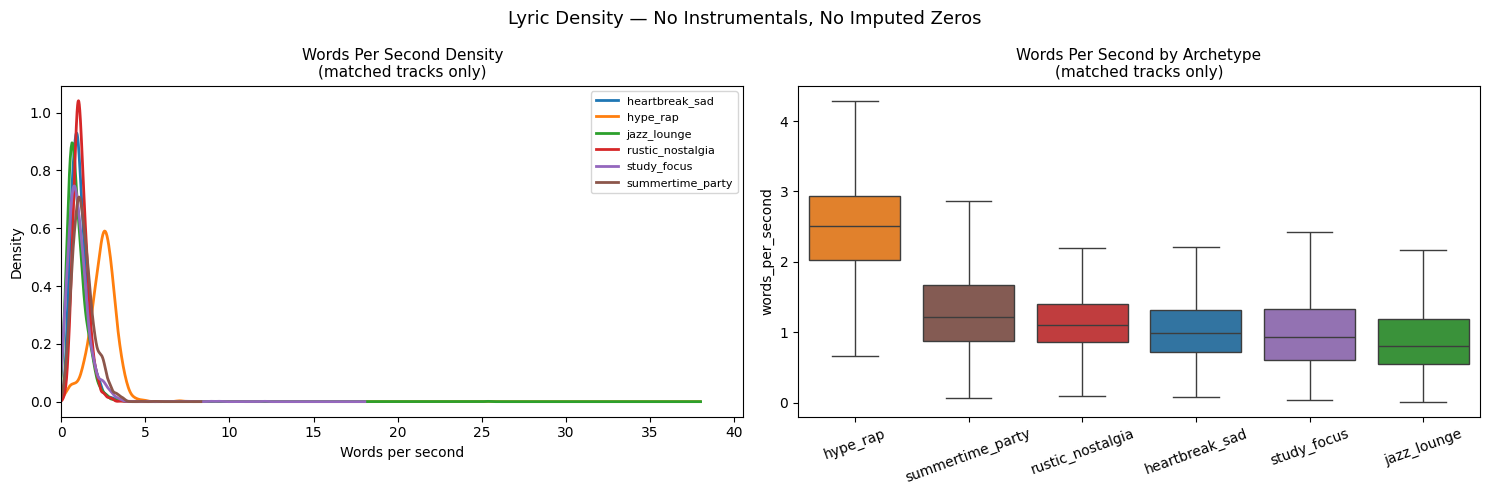

In [ ]:
if "words_per_second" in df.columns:
    wps = matched[matched["words_per_second"].notna() &
                  (matched["words_per_second"] > 0)].copy()
    print(f"Tracks with genuine words_per_second: {len(wps):,}")

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    for arch in ARCHETYPES:
        vals = wps.loc[wps["archetype"] == arch, "words_per_second"]
        if len(vals) > 10:
            vals.plot.kde(ax=axes[0], label=arch,
                          color=PALETTE[arch], linewidth=2)
    axes[0].set_title("Words Per Second Density\n(matched tracks only)", fontsize=11)
    axes[0].set_xlabel("Words per second")
    axes[0].set_xlim(left=0)
    axes[0].legend(fontsize=8)

    order = (wps.groupby("archetype")["words_per_second"]
               .median().sort_values(ascending=False).index.tolist())
    sns.boxplot(data=wps, x="archetype", y="words_per_second",
                order=order, palette=PALETTE, ax=axes[1], showfliers=False)
    axes[1].set_title("Words Per Second by Archetype\n(matched tracks only)",
                      fontsize=11)
    axes[1].set_xlabel("")
    axes[1].tick_params(axis="x", rotation=20)

    plt.suptitle("Lyric Density — No Instrumentals, No Imputed Zeros", fontsize=13)
    plt.tight_layout()
    plt.savefig(f"{EDA_OUT_DIR}/words_per_second.png", dpi=150, bbox_inches="tight")
    plt.show()

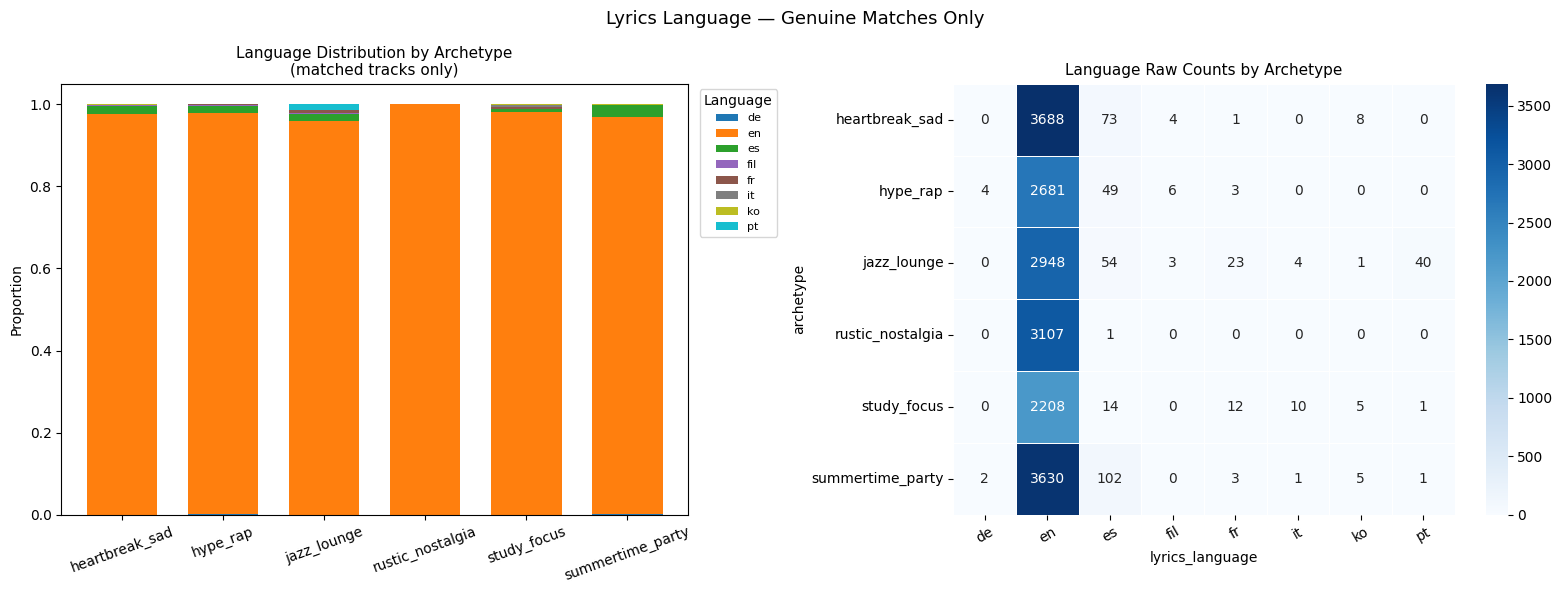

In [ ]:
if "lyrics_language" in df.columns:
    lang_matched  = matched[matched["lyrics_language"].notna()].copy()
    top_langs     = lang_matched["lyrics_language"].value_counts().head(8).index
    lang_filtered = lang_matched[lang_matched["lyrics_language"].isin(top_langs)]

    lang_counts = (
        lang_filtered.groupby(["archetype", "lyrics_language"])
        .size().unstack(fill_value=0)
    )
    lang_props = lang_counts.div(lang_counts.sum(axis=1), axis=0)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    lang_props.plot(kind="bar", stacked=True, ax=axes[0],
                    colormap="tab10", width=0.7)
    axes[0].set_title("Language Distribution by Archetype\n(matched tracks only)",
                      fontsize=11)
    axes[0].set_xlabel("")
    axes[0].set_ylabel("Proportion")
    axes[0].tick_params(axis="x", rotation=20)
    axes[0].legend(title="Language", bbox_to_anchor=(1.01, 1), loc="upper left",
                   fontsize=8)

    sns.heatmap(lang_counts, annot=True, fmt="d", cmap="Blues",
                linewidths=0.5, ax=axes[1])
    axes[1].set_title("Language Raw Counts by Archetype", fontsize=11)
    axes[1].tick_params(axis="x", rotation=30)

    plt.suptitle("Lyrics Language — Genuine Matches Only", fontsize=13)
    plt.tight_layout()
    plt.savefig(f"{EDA_OUT_DIR}/language_distribution.png", dpi=150,
                bbox_inches="tight")
    plt.show()

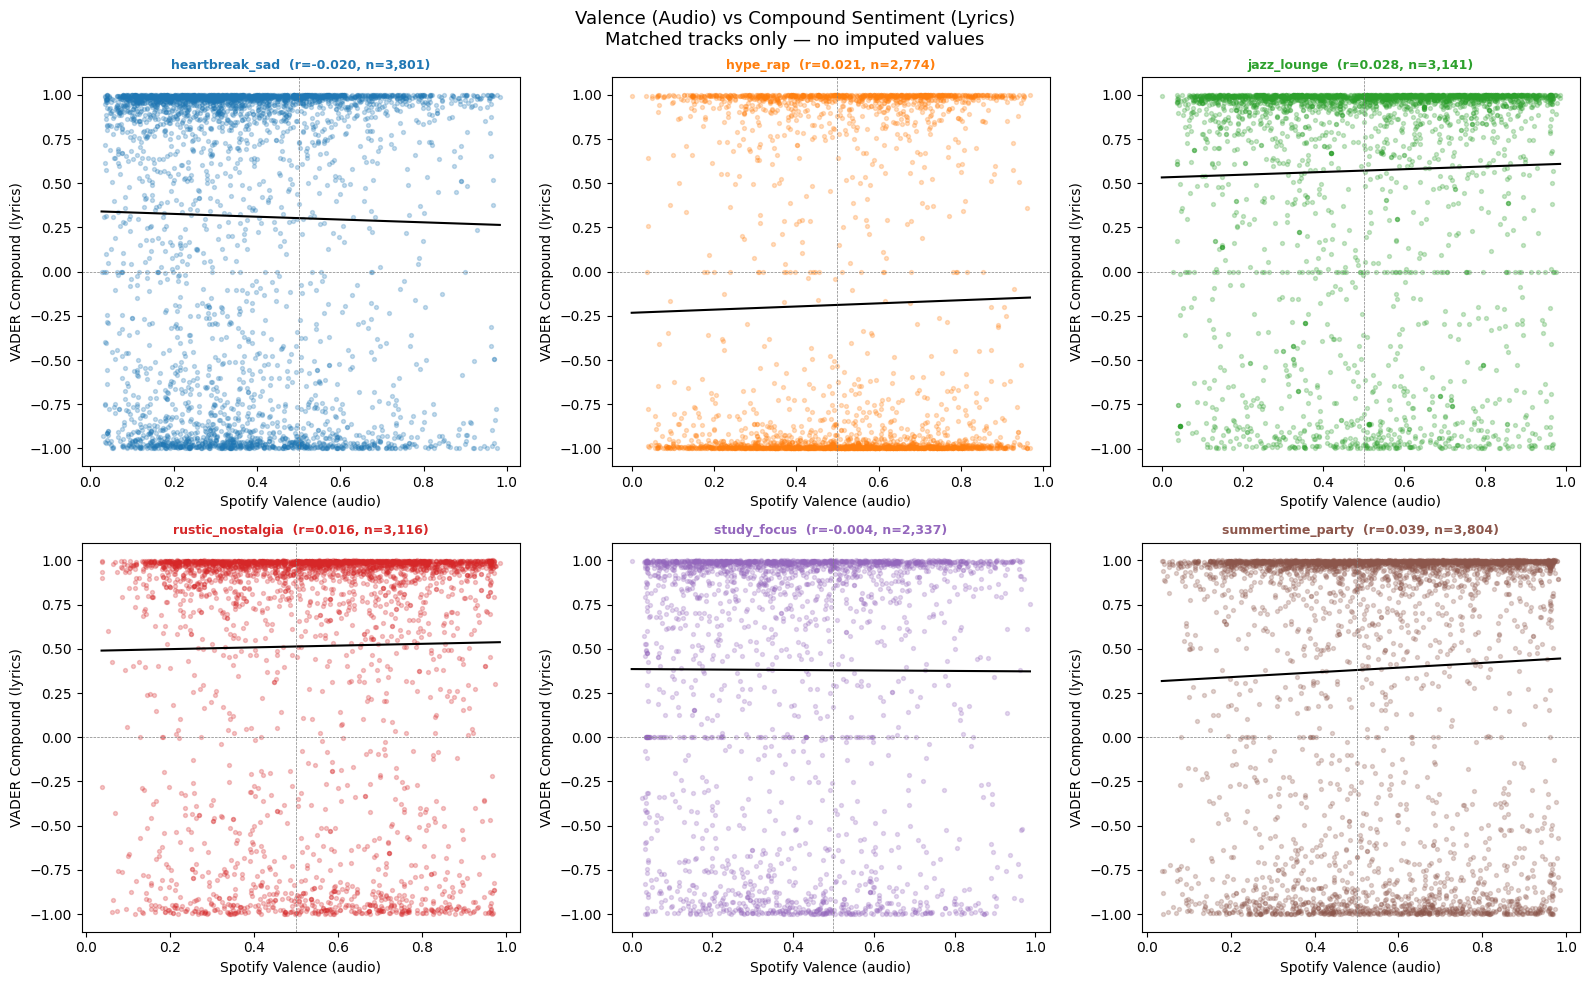


Valence–Compound correlations by archetype:
  summertime_party          r=0.039  → complementary ✓
  jazz_lounge               r=0.028  → complementary ✓
  hype_rap                  r=0.021  → complementary ✓
  heartbreak_sad            r=-0.020  → complementary ✓
  rustic_nostalgia          r=0.016  → complementary ✓
  study_focus               r=-0.004  → complementary ✓


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

corr_summary = {}
for i, arch in enumerate(ARCHETYPES):
    ax     = axes[i]
    subset = matched[
        (matched["archetype"] == arch) &
        matched["lyric_compound_score"].notna() &
        matched["valence"].notna()
    ]
    ax.scatter(subset["valence"], subset["lyric_compound_score"],
               alpha=0.25, s=8, color=PALETTE[arch])
    if len(subset) > 10:
        m, b   = np.polyfit(subset["valence"], subset["lyric_compound_score"], 1)
        x_line = np.linspace(subset["valence"].min(), subset["valence"].max(), 100)
        ax.plot(x_line, m * x_line + b, color="black", linewidth=1.5)
        corr   = subset[["valence", "lyric_compound_score"]].corr().iloc[0, 1]
        corr_summary[arch] = corr
        ax.set_title(f"{arch}  (r={corr:.3f}, n={len(subset):,})",
                     fontsize=9, color=PALETTE[arch], fontweight="bold")
    ax.set_xlabel("Spotify Valence (audio)")
    ax.set_ylabel("VADER Compound (lyrics)")
    ax.axhline(0,   color="gray", linestyle="--", linewidth=0.5)
    ax.axvline(0.5, color="gray", linestyle="--", linewidth=0.5)

for j in range(len(ARCHETYPES), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Valence (Audio) vs Compound Sentiment (Lyrics)", fontsize=13)
plt.tight_layout()
plt.savefig(f"{EDA_OUT_DIR}/valence_vs_compound.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nValence–Compound correlations by archetype:")
for arch, r in sorted(corr_summary.items(), key=lambda x: abs(x[1]), reverse=True):
    signal = "redundant?" if abs(r) > 0.5 else "complementary"
    print(f"  {arch:<25} r={r:.3f}  -> {signal}")

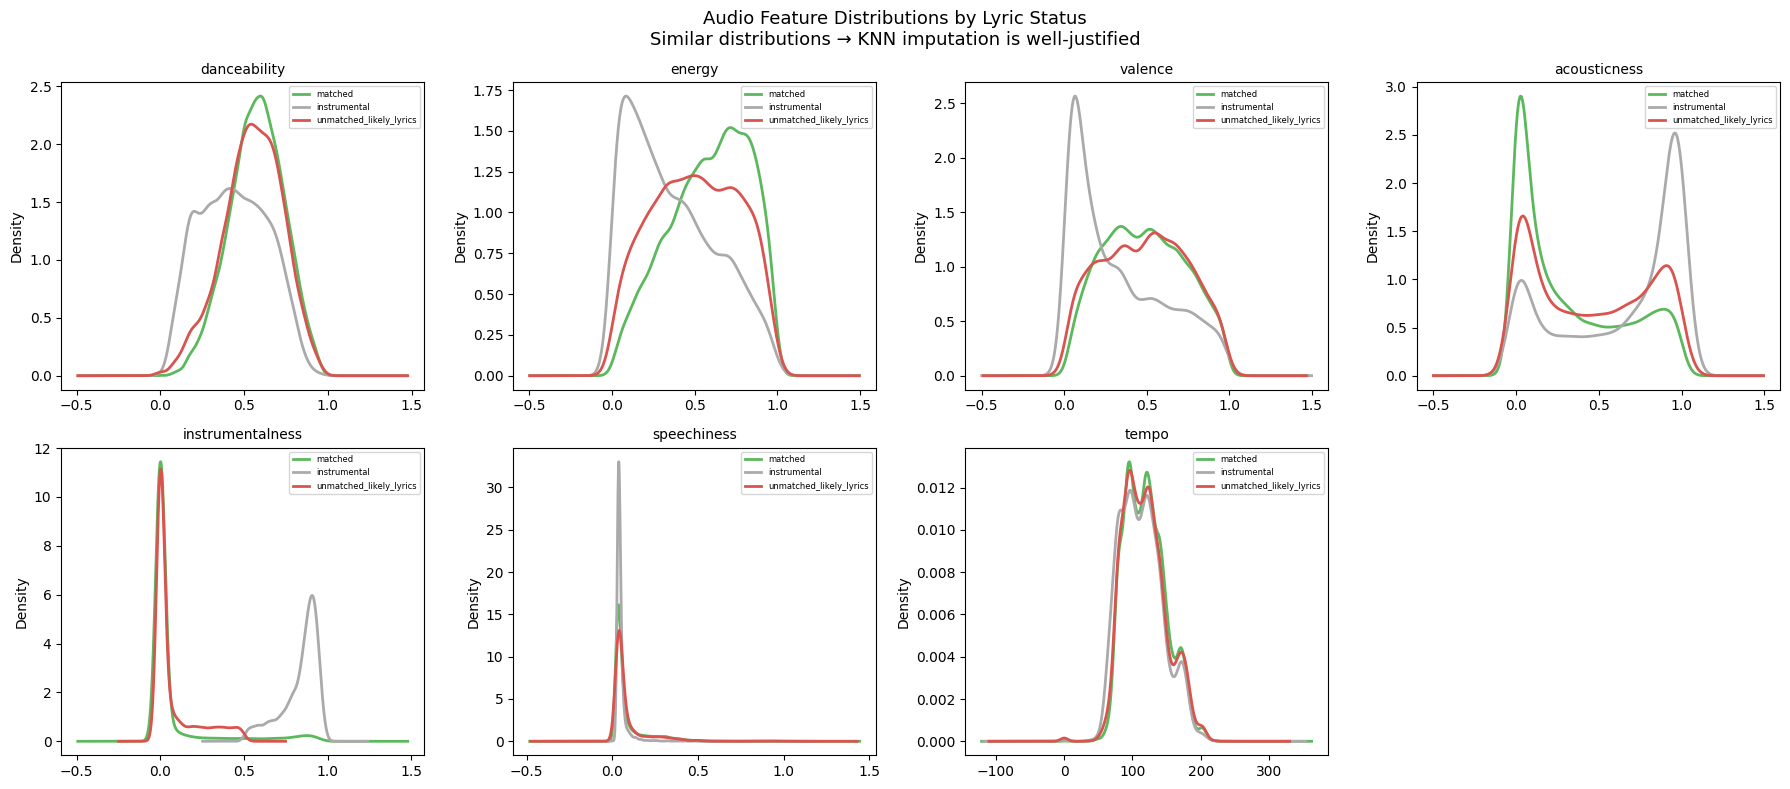


Mean audio features by lyric status:
                         danceability  energy  valence  acousticness  instrumentalness  speechiness    tempo
_lyric_status                                                                                               
instrumental                    0.440   0.364    0.331         0.641             0.836        0.051  113.284
matched                         0.574   0.586    0.489         0.325             0.074        0.086  119.337
unmatched_likely_lyrics         0.550   0.502    0.486         0.451             0.078        0.089  117.981


In [ ]:
audio_cols = ["danceability", "energy", "valence",
              "acousticness", "instrumentalness", "speechiness", "tempo"]
audio_cols = [c for c in audio_cols if c in df.columns]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

status_palette = {
    "matched":                 "#5cb85c",
    "instrumental":            "#aaaaaa",
    "unmatched_likely_lyrics": "#d9534f",
}

for i, col in enumerate(audio_cols):
    ax = axes[i]
    for status, color in status_palette.items():
        vals = df.loc[df["_lyric_status"] == status, col].dropna()
        if len(vals) > 10:
            vals.plot.kde(ax=ax, label=status, color=color, linewidth=2)
    ax.set_title(col, fontsize=10)
    ax.set_xlabel("")
    ax.legend(fontsize=6)

axes[-1].set_visible(False)

plt.suptitle("Audio Feature Distributions by Lyric Status\n"
             "Similar distributions → KNN imputation is well-justified",
             fontsize=13)
plt.tight_layout()
plt.savefig(f"{EDA_OUT_DIR}/missingness_vs_audio.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Statistical summary ───────────────────────────────────────────────────────
print("\nMean audio features by lyric status:")
print(df.groupby("_lyric_status")[audio_cols].mean().round(3).to_string())

In [ ]:
summary_cols = [
    "lyric_compound_score", "lyric_sentiment_pos", "lyric_sentiment_neg",
    "words_per_second", "emotion_score_joy", "emotion_score_sadness",
    "emotion_score_anger", "emotion_score_neutral",
]
summary_cols = [c for c in summary_cols if c in matched.columns]

summary = (
    matched.groupby("archetype")[summary_cols]
    .agg(["count", "mean", "median", "std"])
    .round(4)
)

print("Lyric Feature Summary Stats (genuine matches only):\n")
print(summary.to_string())
summary.to_csv(f"{EDA_OUT_DIR}/lyric_eda_summary_raw.csv")
print(f"\n✓ Summary saved → {EDA_OUT_DIR}/lyric_eda_summary_raw.csv")
print(f"✓ All plots saved → {EDA_OUT_DIR}/")

Lyric Feature Summary Stats (genuine matches only):

                 lyric_compound_score                         lyric_sentiment_pos                        lyric_sentiment_neg                        words_per_second                         emotion_score_joy                         emotion_score_sadness                         emotion_score_anger                         emotion_score_neutral                        
                                count    mean  median     std               count    mean median     std               count    mean median     std            count    mean  median     std             count    mean  median     std                 count    mean  median     std               count    mean  median     std                 count    mean  median     std
archetype                                                                                                                                                                                                            

#Data Prep for ML

###Imports and Config

In [1]:
!pip install scikit-learn --quiet

In [4]:
import os
import json
import numpy as np
import pandas as pd
from google.colab import drive
from sklearn.impute import KNNImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

drive.mount('/content/drive')

DRIVE_OUTPUT_DIR = "/content/drive/MyDrive/lyrics_pipeline"
ENRICHED_CSV = "dataset_with_lyrics_FINAL.csv" #os.path.join(DRIVE_OUTPUT_DIR, "dataset_with_lyrics_FINAL.csv")
ML_OUTPUT_DIR = "/content/drive/MyDrive/CIS_2450_Final_Project/ml_ready"
os.makedirs(ML_OUTPUT_DIR, exist_ok=True)

AUDIO_FEATURES = [
    "danceability", "energy", "key", "loudness", "mode",
    "speechiness", "acousticness", "instrumentalness",
    "liveness", "valence", "tempo", "duration_ms", "time_signature", "year"
]

LYRIC_NUMERIC_FEATURES = [
    "words_per_second",
    "lyric_sentiment_pos", "lyric_sentiment_neg",
    "lyric_sentiment_neu", "lyric_compound_score",
    "emotion_score_anger", "emotion_score_disgust", "emotion_score_fear",
    "emotion_score_joy", "emotion_score_neutral",
    "emotion_score_sadness", "emotion_score_surprise",
    "lyric_arch_sim_study_focus", "lyric_arch_sim_heartbreak_sad",
    "lyric_arch_sim_summertime_party", "lyric_arch_sim_rustic_nostalgia",
    "lyric_arch_sim_jazz_lounge", "lyric_arch_sim_hype_rap",
]

TARGET = "archetype"
KNN_K  = 5

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


###Load Enriched (Audio+Lyrical) Dataset

In [5]:
print("Loading enriched lyrics dataset...")
df = pd.read_csv(ENRICHED_CSV)
print(f"  Shape: {df.shape}")
print(f"\nArchetype distribution (pre-dedup):")
print(df[TARGET].value_counts())

Loading enriched lyrics dataset...
  Shape: (45164, 47)

Archetype distribution (pre-dedup):
archetype
study_focus         11419
jazz_lounge          9897
summertime_party     7860
heartbreak_sad       6966
rustic_nostalgia     4577
hype_rap             4445
Name: count, dtype: int64


###deduplicate inter-class duplicates

In [6]:
print("\nDeduplicating by spotify_track_id (keep max total_arch_score)...")
df = (
    df.sort_values("total_arch_score", ascending=False)
      .drop_duplicates(subset="spotify_track_id", keep="first")
      .reset_index(drop=True)
)
print(f"Shape after dedup: {df.shape}")
print(f"\nArchetype distribution (post-dedup):")
print(df[TARGET].value_counts())


Deduplicating by spotify_track_id (keep max total_arch_score)...
Shape after dedup: (32112, 47)

Archetype distribution (post-dedup):
archetype
study_focus         8105
jazz_lounge         7748
summertime_party    4692
heartbreak_sad      4489
rustic_nostalgia    3592
hype_rap            3486
Name: count, dtype: int64


###Train-Test Split

In [7]:
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df["archetype"]
)
train_df = train_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)
print(f"Train: {len(train_df):,} | Test: {len(test_df):,}")

Train: 25,689 | Test: 6,423


###Impute Missing Values For Instrumental/Unmatched tracks

In [10]:
print("Applying imputation...")

INSTRUMENTAL_THRESHOLD = 0.5

def get_masks(split_df):
    is_instrumental = (
        split_df["instrumentalness"] >= INSTRUMENTAL_THRESHOLD
    ) | (
        (split_df.get("has_lyrics", pd.Series(1, index=split_df.index)) == 0) &
        (split_df["instrumentalness"] >= 0.3)
    )
    is_unmatched = (
        ~is_instrumental &
        (split_df.get("has_lyrics", pd.Series(1, index=split_df.index)) == 0)
    )
    return is_instrumental, is_unmatched

train_is_instrumental, train_is_unmatched = get_masks(train_df)
test_is_instrumental,  test_is_unmatched  = get_masks(test_df)

print(f"  Train — instrumental: {train_is_instrumental.sum():,} | "
      f"unmatched: {train_is_unmatched.sum():,}")
print(f"  Test  — instrumental: {test_is_instrumental.sum():,}  | "
      f"unmatched: {test_is_unmatched.sum():,}")

emotion_cols  = [c for c in LYRIC_NUMERIC_FEATURES if "emotion_score" in c]
arch_sim_cols = [c for c in LYRIC_NUMERIC_FEATURES if "arch_sim" in c]

#INSTRUMENTAL: structural fills (identical constants, no statistics)
for split_df, is_instrumental in [(train_df, train_is_instrumental),
                                   (test_df,  test_is_instrumental)]:
    for col, fill_val in [
        ("lyric_sentiment_pos",  0.0),
        ("lyric_sentiment_neg",  0.0),
        ("lyric_sentiment_neu",  1.0),
        ("lyric_compound_score", 0.0),
        ("words_per_second",     0.0),
    ]:
        if col in split_df.columns:
            split_df.loc[is_instrumental, col] = \
                split_df.loc[is_instrumental, col].fillna(fill_val)

    for col in emotion_cols:
        if col in split_df.columns:
            fill_val = 1.0 if col == "emotion_score_neutral" else 0.0
            split_df.loc[is_instrumental, col] = \
                split_df.loc[is_instrumental, col].fillna(fill_val)

    for col in arch_sim_cols:
        if col in split_df.columns:
            split_df.loc[is_instrumental, col] = \
                split_df.loc[is_instrumental, col].fillna(0.0)

    if "dominant_emotion" in split_df.columns:
        split_df.loc[is_instrumental & split_df["dominant_emotion"].isna(),
                     "dominant_emotion"] = "neutral"
    if "lyrics_language" in split_df.columns:
        split_df.loc[is_instrumental & split_df["lyrics_language"].isna(),
                     "lyrics_language"] = "instrumental"

print("  Instrumental structural imputation complete.")

#UNMATCHED: class-conditional means from train matched rows
sentiment_cols = [
    "lyric_sentiment_pos", "lyric_sentiment_neg",
    "lyric_sentiment_neu", "lyric_compound_score",
]
all_lyric_numeric = (
    sentiment_cols + emotion_cols + arch_sim_cols +
    (["words_per_second"] if "words_per_second" in train_df.columns else [])
)
all_lyric_numeric = [c for c in all_lyric_numeric if c in train_df.columns]

train_matched_mask = train_df.get(
    "has_lyrics", pd.Series(1, index=train_df.index)
) == 1
class_means = (
    train_df[train_matched_mask]
    .groupby("archetype")[all_lyric_numeric]
    .mean()
)
print(f"\n Class-conditional means from {train_matched_mask.sum():,}")

for split_df, is_unmatched in [(train_df, train_is_unmatched),
                                (test_df,  test_is_unmatched)]:
    for arch in split_df["archetype"].unique():
        if arch not in class_means.index:
            continue
        arch_mask = is_unmatched & (split_df["archetype"] == arch)
        if arch_mask.sum() == 0:
            continue
        for col in all_lyric_numeric:
            null_mask = arch_mask & split_df[col].isna()
            if null_mask.sum() > 0:
                split_df.loc[null_mask, col] = class_means.loc[arch, col]

    if "dominant_emotion" in split_df.columns:
        split_df.loc[is_unmatched & split_df["dominant_emotion"].isna(),
                     "dominant_emotion"] = "unknown"
    if "lyrics_language" in split_df.columns:
        split_df.loc[is_unmatched & split_df["lyrics_language"].isna(),
                     "lyrics_language"] = "unknown"

print("Class-conditional imputation complete.")
print("Imputation done.")

Applying imputation...
  Train — instrumental: 7,212 | unmatched: 4,370
  Test  — instrumental: 1,791  | unmatched: 1,098
  Instrumental structural imputation complete.

 Class-conditional means from 15,160
Class-conditional imputation complete.
Imputation done.


###Encode Categorical Features

In [11]:
print("\nEncoding categorical features...")

# explicit: bool -> 1/0
for split_df in [train_df, test_df]:
    if "explicit" in split_df.columns:
        split_df["explicit"] = (
            split_df["explicit"].astype(str).str.upper().str.strip()
            .map({"TRUE": 1, "FALSE": 0, "1": 1, "0": 0})
            .fillna(0).astype(int)
        )
print("  explicit → binary int")

# dominant_emotion: fit on train, transform both
le_emotion = LabelEncoder()
if "dominant_emotion" in train_df.columns:
    train_df["dominant_emotion"] = train_df["dominant_emotion"].fillna("unknown")
    test_df["dominant_emotion"]  = test_df["dominant_emotion"].fillna("unknown")

    le_emotion.fit(train_df["dominant_emotion"])

    # Handle unseen labels in test gracefully
    known = set(le_emotion.classes_)
    test_df["dominant_emotion"] = test_df["dominant_emotion"].apply(
        lambda x: x if x in known else "unknown"
    )
    train_df["dominant_emotion_enc"] = le_emotion.transform(train_df["dominant_emotion"])
    test_df["dominant_emotion_enc"]  = le_emotion.transform(test_df["dominant_emotion"])
    print(f"  dominant_emotion classes: {list(le_emotion.classes_)}")

#lyrics_language: fit on train, transform both
le_lang = LabelEncoder()
if "lyrics_language" in train_df.columns:
    train_df["lyrics_language"] = train_df["lyrics_language"].fillna("unknown")
    test_df["lyrics_language"]  = test_df["lyrics_language"].fillna("unknown")

    le_lang.fit(train_df["lyrics_language"])

    known_langs = set(le_lang.classes_)
    test_df["lyrics_language"] = test_df["lyrics_language"].apply(
        lambda x: x if x in known_langs else "unknown"
    )
    train_df["lyrics_language_enc"] = le_lang.transform(train_df["lyrics_language"])
    test_df["lyrics_language_enc"]  = le_lang.transform(test_df["lyrics_language"])
    print(f"  lyrics_language unique (train): {train_df['lyrics_language'].nunique()} classes")

#is_english: binary
for split_df in [train_df, test_df]:
    if "lyrics_language" in split_df.columns:
        split_df["is_english"] = (split_df["lyrics_language"] == "en").astype(int)
print("  Added is_english binary feature")


Encoding categorical features...
  explicit → binary int
  dominant_emotion classes: ['anger', 'disgust', 'fear', 'joy', 'neutral', 'sadness', 'surprise', 'unknown']
  lyrics_language unique (train): 18 classes
  Added is_english binary feature


###Impute Lyrical Nulls with KNN

In [12]:
print("\nRunning KNN imputation on remaining lyric nulls...")

lyric_cols_to_impute = [
    c for c in LYRIC_NUMERIC_FEATURES
    if c in train_df.columns and (
        train_df[c].isna().any() or test_df[c].isna().any()
    )
]
print(f"Cols with remaining nulls: {lyric_cols_to_impute}")

if lyric_cols_to_impute:
    knn_basis_cols = [c for c in AUDIO_FEATURES if c in train_df.columns]
    impute_cols    = knn_basis_cols + lyric_cols_to_impute

    train_non_inst = ~train_is_instrumental
    test_non_inst  = ~test_is_instrumental

    train_subset = train_df.loc[train_non_inst, impute_cols].copy()
    test_subset  = test_df.loc[test_non_inst,  impute_cols].copy()

    print(f"Fitting KNN (k={KNN_K}) on {train_non_inst.sum():,} "
          f"non-instrumental TRAIN rows...")
    imputer = KNNImputer(n_neighbors=KNN_K)
    train_imputed = imputer.fit_transform(train_subset) #fit + transform train
    test_imputed = imputer.transform(test_subset) #transform test only

    train_imputed_df = pd.DataFrame(train_imputed, columns=impute_cols,
                                    index=train_subset.index)
    test_imputed_df  = pd.DataFrame(test_imputed,  columns=impute_cols,
                                    index=test_subset.index)

    for col in lyric_cols_to_impute:
        train_df.loc[train_non_inst, col] = train_imputed_df[col]
        test_df.loc[test_non_inst,   col] = test_imputed_df[col]

    print("KNN imputation complete.")
else:
    print("No nulls in lyric features—skipping KNN")


Running KNN imputation on remaining lyric nulls...
Cols with remaining nulls: ['emotion_score_anger', 'emotion_score_disgust', 'emotion_score_fear', 'emotion_score_joy', 'emotion_score_neutral', 'emotion_score_sadness', 'emotion_score_surprise']
  Fitting KNN (k=5) on 18,477 non-instrumental TRAIN rows...
  KNN imputation complete.


In EDA, we found that the tracks that were no audiologically resemblent of instrumental tracks had high audiological resemblence with tracks that were matched with lyrics, so using KNN to impute lyrical values for training data will likely work well.

###Final Feature Matrices

In [13]:
print("\nAssembling...")

ENCODED_CATS = []
for col in ["dominant_emotion_enc", "lyrics_language_enc",
            "is_english", "explicit", "has_lyrics"]:
    if col in train_df.columns:
        ENCODED_CATS.append(col)

ALL_FEATURES = [
    c for c in (AUDIO_FEATURES + LYRIC_NUMERIC_FEATURES + ENCODED_CATS)
    if c in train_df.columns
]
print(f"Total features: {len(ALL_FEATURES)}")

X_train = train_df[ALL_FEATURES].copy()
y_train = train_df[TARGET].copy()
X_test  = test_df[ALL_FEATURES].copy()
y_test  = test_df[TARGET].copy()

#null check
for split_name, X_split, ref_df in [("train", X_train, train_df),
                                     ("test",  X_test,  train_df)]:
    remaining = X_split.isna().sum()
    remaining = remaining[remaining > 0]
    if len(remaining) > 0:
        print(f"\n  [WARN] {split_name} remaining nulls — filling with TRAIN median:")
        print(remaining)
        for col in remaining.index:
            X_split[col] = X_split[col].fillna(train_df[col].median())
    else:
        print(f"{split_name}: no remaining nulls.")

print(f"\nX_train: {X_train.shape} | X_test: {X_test.shape}")
print(f"y_train distribution:\n{y_train.value_counts()}")
print(f"y_test distribution:\n{y_test.value_counts()}")


Assembling...
Total features: 37
train: no remaining nulls.
test: no remaining nulls.

X_train: (25689, 37) | X_test: (6423, 37)
y_train distribution:
archetype
study_focus         6484
jazz_lounge         6198
summertime_party    3753
heartbreak_sad      3591
rustic_nostalgia    2874
hype_rap            2789
Name: count, dtype: int64
y_test distribution:
archetype
study_focus         1621
jazz_lounge         1550
summertime_party     939
heartbreak_sad       898
rustic_nostalgia     718
hype_rap             697
Name: count, dtype: int64


###Save to CSV

In [14]:
X_train.to_csv(os.path.join(ML_OUTPUT_DIR, "X_train.csv"), index=False)
X_test.to_csv( os.path.join(ML_OUTPUT_DIR, "X_test.csv"),  index=False)
y_train.to_csv(os.path.join(ML_OUTPUT_DIR, "y_train.csv"), index=False)
y_test.to_csv( os.path.join(ML_OUTPUT_DIR, "y_test.csv"),  index=False)
print("X_train, X_test, y_train, y_test saved.")

meta = {
    "n_features":               len(ALL_FEATURES),
    "n_train":                  len(X_train),
    "n_test":                   len(X_test),
    "features":                 ALL_FEATURES,
    "audio_features":           [c for c in AUDIO_FEATURES if c in ALL_FEATURES],
    "lyric_features":           [c for c in LYRIC_NUMERIC_FEATURES if c in ALL_FEATURES],
    "categorical_encoded":      ENCODED_CATS,
    "target_classes":           sorted(y_train.unique().tolist()),
    "dominant_emotion_classes": list(le_emotion.classes_) if "dominant_emotion_enc" in train_df.columns else [],
    "language_classes":         list(le_lang.classes_) if "lyrics_language_enc" in train_df.columns else [],
    "knn_k":                    KNN_K,
    "fuzzy_threshold":          85,
    "instrumental_threshold":   INSTRUMENTAL_THRESHOLD,
}
with open(os.path.join(ML_OUTPUT_DIR, "feature_metadata.json"), "w") as f:
    json.dump(meta, f, indent=2)
print("Metadata saved")

print("\n--- ML prep complete ---")
print(f"Train: {len(X_train):,} samples | Test: {len(X_test):,} samples")
print(f"Features: {len(ALL_FEATURES)}")
print(f"Classes: {sorted(y_train.unique())}")

X_train, X_test, y_train, y_test saved.
Metadata saved

--- ML prep complete ---
Train: 25,689 samples | Test: 6,423 samples
Features: 37
Classes: ['heartbreak_sad', 'hype_rap', 'jazz_lounge', 'rustic_nostalgia', 'study_focus', 'summertime_party']


#ML

##Imports, Config, and Load Data

In [35]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score
)

drive.mount('/content/drive')

ML_OUTPUT_DIR = "/content/drive/MyDrive/CIS_2450_Final_Project/ml_ready"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [36]:
X_train = pd.read_csv(f"{ML_OUTPUT_DIR}/X_train.csv")
X_test  = pd.read_csv(f"{ML_OUTPUT_DIR}/X_test.csv")
y_train = pd.read_csv(f"{ML_OUTPUT_DIR}/y_train.csv").squeeze()
y_test  = pd.read_csv(f"{ML_OUTPUT_DIR}/y_test.csv").squeeze()

with open(f"{ML_OUTPUT_DIR}/feature_metadata.json") as f:
    meta = json.load(f)

print(f"X_train: {X_train.shape} | X_test: {X_test.shape}")
print(f"\ny_train distribution:\n{y_train.value_counts()}")
print(f"\ny_test distribution:\n{y_test.value_counts()}")
print(f"\nFeature groups:")
print(f"  Audio:       {len(meta['audio_features'])}")
print(f"  Lyric:       {len(meta['lyric_features'])}")
print(f"  Categorical: {len(meta['categorical_encoded'])}")

X_train: (25689, 37) | X_test: (6423, 37)

y_train distribution:
archetype
study_focus         6484
jazz_lounge         6198
summertime_party    3753
heartbreak_sad      3591
rustic_nostalgia    2874
hype_rap            2789
Name: count, dtype: int64

y_test distribution:
archetype
study_focus         1621
jazz_lounge         1550
summertime_party     939
heartbreak_sad       898
rustic_nostalgia     718
hype_rap             697
Name: count, dtype: int64

Feature groups:
  Audio:       14
  Lyric:       18
  Categorical: 5


##Baseline Models

Logistic Regression performed decent on the dataset (59% accuracy), but it was slightly outperformed by the Decision Tree which had 60% accuracy

###Logistic Regression

In [18]:
AUDIO_FEATURES = [
    "danceability", "energy", "key", "loudness", "mode",
    "speechiness", "acousticness", "instrumentalness",
    "liveness", "valence", "tempo", "duration_ms", "time_signature", "year"
]
LYRIC_NUMERIC_FEATURES = [
    "words_per_second",
    "lyric_sentiment_pos", "lyric_sentiment_neg",
    "lyric_sentiment_neu", "lyric_compound_score",
    "emotion_score_anger", "emotion_score_disgust", "emotion_score_fear",
    "emotion_score_joy", "emotion_score_neutral",
    "emotion_score_sadness", "emotion_score_surprise",
    "lyric_arch_sim_study_focus", "lyric_arch_sim_heartbreak_sad",
    "lyric_arch_sim_summertime_party", "lyric_arch_sim_rustic_nostalgia",
    "lyric_arch_sim_jazz_lounge", "lyric_arch_sim_hype_rap",
]
CATEGORICAL_FEATURES = [
    "dominant_emotion_enc", "lyrics_language_enc",
    "is_english", "explicit", "has_lyrics"
]
NUMERIC_FEATURES = AUDIO_FEATURES + LYRIC_NUMERIC_FEATURES

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

preprocessor = ColumnTransformer(transformers=[
    ("scale", StandardScaler(), NUMERIC_FEATURES),
    ("passthrough", "passthrough", CATEGORICAL_FEATURES),
])

lr_baseline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        C=1.0,
        penalty="l2",
        solver="saga",
        multi_class="multinomial",
        class_weight="balanced",
        max_iter=1000,
        random_state=42,
        n_jobs=-1,
    ))
])

print("Logistic Regression")
lr_baseline.fit(X_train, y_train)

lr_pred_train = lr_baseline.predict(X_train)
lr_pred_test  = lr_baseline.predict(X_test)

print(f"Train acc: {accuracy_score(y_train, lr_pred_train):.4f}")
print(f"Test accuracy: {accuracy_score(y_test,  lr_pred_test):.4f}")
print(f"Test macro-F1 : {f1_score(y_test, lr_pred_test, average='macro'):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, lr_pred_test))


Logistic Regression


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Train acc : 0.5818
Test accuracy : 0.5868
Test macro-F1  : 0.5877

Classification Report:
                  precision    recall  f1-score   support

  heartbreak_sad       0.45      0.54      0.49       898
        hype_rap       0.78      0.86      0.81       697
     jazz_lounge       0.69      0.57      0.62      1550
rustic_nostalgia       0.44      0.63      0.51       718
     study_focus       0.73      0.58      0.64      1621
summertime_party       0.43      0.45      0.44       939

        accuracy                           0.59      6423
       macro avg       0.58      0.60      0.59      6423
    weighted avg       0.61      0.59      0.59      6423



###Decision Tree

In [37]:
from sklearn.tree import DecisionTreeClassifier

dt_baseline = DecisionTreeClassifier(
    max_depth=10,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42,
)

print("Decision Tree")
dt_baseline.fit(X_train, y_train)

dt_pred_train = dt_baseline.predict(X_train)
dt_pred_test  = dt_baseline.predict(X_test)

print(f"Train accuracy : {accuracy_score(y_train, dt_pred_train):.4f}")
print(f"Test accuracy : {accuracy_score(y_test,  dt_pred_test):.4f}")
print(f"Test macro-F1  : {f1_score(y_test, dt_pred_test, average='macro'):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, dt_pred_test))

Decision Tree
Train accuracy : 0.6496
Test accuracy : 0.5999
Test macro-F1  : 0.5948

Classification Report:
                  precision    recall  f1-score   support

  heartbreak_sad       0.42      0.55      0.48       898
        hype_rap       0.75      0.80      0.78       697
     jazz_lounge       0.78      0.58      0.67      1550
rustic_nostalgia       0.40      0.61      0.49       718
     study_focus       0.83      0.62      0.71      1621
summertime_party       0.43      0.47      0.45       939

        accuracy                           0.60      6423
       macro avg       0.60      0.61      0.59      6423
    weighted avg       0.65      0.60      0.61      6423



Hyperparameter Tuning

In [39]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "max_depth": [10, 15, 20, 25],
    "min_samples_leaf": [30, 35, 40, 50, 60, 80],
    "criterion": ["gini", "entropy"],
}

grid_search = GridSearchCV(
    DecisionTreeClassifier(class_weight="balanced", random_state=42),
    param_grid,
    cv=3,
    scoring="f1_macro",
    n_jobs=-1,
    verbose=1,
)
grid_search.fit(X_train, y_train)

dt_best = grid_search.best_estimator_
print(f"Best params: {grid_search.best_params_}")
print(f"CV macro-F1: {grid_search.best_score_:.4f}")

dt_pred_train = dt_best.predict(X_train)
dt_pred_test = dt_best.predict(X_test)
print(f"Train accuracy : {accuracy_score(y_train, dt_pred_train):.4f}")
print(f"Test accuracy : {accuracy_score(y_test,  dt_pred_test):.4f}")
print(f"Test macro-F1: {f1_score(y_test, dt_pred_test, average='macro'):.4f}")
print(classification_report(y_test, dt_pred_test))

Fitting 3 folds for each of 48 candidates, totalling 144 fits
Best params: {'criterion': 'entropy', 'max_depth': 20, 'min_samples_leaf': 50}
CV macro-F1: 0.6046
Train accuracy : 0.6558
Test accuracy : 0.6083
Test macro-F1: 0.6039
                  precision    recall  f1-score   support

  heartbreak_sad       0.42      0.54      0.47       898
        hype_rap       0.78      0.83      0.80       697
     jazz_lounge       0.74      0.60      0.66      1550
rustic_nostalgia       0.44      0.59      0.50       718
     study_focus       0.82      0.63      0.72      1621
summertime_party       0.44      0.50      0.47       939

        accuracy                           0.61      6423
       macro avg       0.61      0.61      0.60      6423
    weighted avg       0.64      0.61      0.62      6423



##Random Forests

###Baseline RF

Our Baseline RF substantially outperformed our baseline models with 68.5% accuracy

####Train/Eval

In [3]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
)

print(f"Train: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,}")
print(f"\nTrain class distribution:")
print(y_train.value_counts())
print("\nTraining Random Forest...")
rf.fit(X_train, y_train)
print("Done.")

Train: 25,689 | Test: 6,423

Train class distribution:
archetype
study_focus         6484
jazz_lounge         6198
summertime_party    3753
heartbreak_sad      3591
rustic_nostalgia    2874
hype_rap            2789
Name: count, dtype: int64

Training Random Forest...
Done.


In [29]:
y_pred = rf.predict(X_test)
y_pred_train = rf.predict(X_train)

test_acc = accuracy_score(y_test, y_pred)
train_acc = accuracy_score(y_train, y_pred_train)
test_f1 = f1_score(y_test, y_pred, average="macro")

print(f"Train acc: {train_acc:.4f}")
print(f"Test acc: {test_acc:.4f}")
print(f"Test macro F1: {test_f1:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred))

Train acc: 0.9828
Test acc: 0.6853
Test macro F1: 0.6810

Classification Report:
                  precision    recall  f1-score   support

  heartbreak_sad       0.53      0.63      0.57       898
        hype_rap       0.79      0.87      0.83       697
     jazz_lounge       0.79      0.69      0.74      1550
rustic_nostalgia       0.62      0.65      0.63       718
     study_focus       0.83      0.68      0.75      1621
summertime_party       0.52      0.62      0.56       939

        accuracy                           0.69      6423
       macro avg       0.68      0.69      0.68      6423
    weighted avg       0.70      0.69      0.69      6423



####Analysis

In [9]:
classes = sorted(y_test.unique())
cm = confusion_matrix(y_test, y_pred, labels=classes)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)  #row-normalized

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Raw counts
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=classes, yticklabels=classes, ax=axes[0])
axes[0].set_title("Confusion Matrix — Raw Counts")
axes[0].set_ylabel("True Label")
axes[0].set_xlabel("Predicted Label")
axes[0].tick_params(axis="x", rotation=30)

# Row-normalized (recall per class on diagonal)
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=classes, yticklabels=classes, ax=axes[1])
axes[1].set_title("Confusion Matrix — Row Normalized (Recall)")
axes[1].set_ylabel("True Label")
axes[1].set_xlabel("Predicted Label")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig(f"{ML_OUTPUT_DIR}/confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()


NameError: name 'y_pred' is not defined

In [ ]:
importances = pd.Series(rf.feature_importances_, index=X_train.columns)
top = importances.sort_values()

# Color bars by feature group for readability
group_colors = {}
for c in meta["audio_features"]: group_colors[c] = "#4C72B0"
for c in meta["lyric_features"]: group_colors[c] = "#DD8452"
for c in meta["categorical_encoded"]:  group_colors[c] = "#C44E52"
colors = [group_colors.get(f, "#8C8C8C") for f in top.index]

fig, ax = plt.subplots(figsize=(10, 10))
top.plot(kind="barh", ax=ax, color=colors)
ax.set_title("Feature Importances")
ax.set_xlabel("Mean Decrease in Impurity")

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(color="#4C72B0", label="Audio"),
    Patch(color="#DD8452", label="Lyric"),
    #Patch(color="#55A868", label="Last.fm"),
    Patch(color="#C44E52", label="Categorical"),
]
ax.legend(handles=legend_elements, loc="lower right")
plt.tight_layout()
plt.savefig(f"{ML_OUTPUT_DIR}/feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

In [10]:
def eval_feature_subset(name, cols, X_tr, X_te, y_tr, y_te):
    cols = [c for c in cols if c in X_tr.columns]
    if not cols:
        print(f"  {name}: no columns found, skipping.")
        return
    clf = RandomForestClassifier(
        n_estimators=200, min_samples_leaf=2,
        class_weight="balanced", random_state=42, n_jobs=-1
    )
    clf.fit(X_tr[cols], y_tr)
    preds = clf.predict(X_te[cols])
    acc = accuracy_score(y_te, preds)
    f1  = f1_score(y_te, preds, average="macro")
    print(f"  {name:<30} acc={acc:.4f}  macro_f1={f1:.4f}  (n_features={len(cols)})")

print("Feature group ablation study:\n")
eval_feature_subset("Audio only",
    meta["audio_features"],
    X_train, X_test, y_train, y_test)

eval_feature_subset("Lyric only",
    meta["lyric_features"] + meta["categorical_encoded"],
    X_train, X_test, y_train, y_test)

eval_feature_subset("Audio + Lyric",
    meta["audio_features"] + meta["lyric_features"] + meta["categorical_encoded"],
    X_train, X_test, y_train, y_test)

Feature group ablation study:

  Audio only                     acc=0.5851  macro_f1=0.5734  (n_features=14)
  Lyric only                     acc=0.5865  macro_f1=0.5814  (n_features=23)
  Audio + Lyric                  acc=0.6815  macro_f1=0.6770  (n_features=37)


Audio and lyrical data is providing *real* insight into the data and assistance to discern its vibe.

###Hyperparameter Tuning: Bayesian Optimization

Our Hyperparameter tuned RF marginally outperformed the Baseline RF with an accuracy of 68.6% (a .1% increase). However,

####Install Optuna

In [5]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 8.5 MB/s eta 0:00:00


####Setup

In [6]:
import optuna
from optuna.samplers import TPESampler
from sklearn.model_selection import StratifiedKFold, cross_val_score

optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial: optuna.Trial) -> float:
    params = {
        #Number of trees
        "n_estimators": trial.suggest_int("n_estimators", 100, 400, step=50),

        #Tree depth:
        "max_depth": trial.suggest_int("max_depth", 5, 40),

        #Min samples to keep a leaf
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 20),

        #Min samples to split an internal node
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),

        #Feature sub-sampling per split
        "max_features": trial.suggest_categorical(
            "max_features", ["sqrt", "log2", 0.3, 0.5, 0.7]
        ),

        #Sub-sample rows per tree
        "max_samples": trial.suggest_float("max_samples", 0.5, 1.0),

        #Class imbalance handling
        "class_weight": "balanced",
        "bootstrap": True,
        "random_state": 42,
        "n_jobs": -1,
    }

    model = RandomForestClassifier(**params)

    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    scores = cross_val_score(
        model, X_train, y_train,
        cv=cv,
        scoring="f1_macro",
        n_jobs=-1,
    )
    return scores.mean()

####Run

In [7]:
print("Bayesian Hyperparameter Search (Optuna/TPE)")
print(f"Search space: 7 hyperparameters")
print(f"Trials: 60")
print(f"CV folds: 3 (StratifiedKFold, macro-F1)")

sampler = TPESampler(seed=42)
study = optuna.create_study(direction="maximize", sampler=sampler)

# Warm-start with current config so we know the baseline
study.enqueue_trial({
    "n_estimators": 300,
    "max_depth": 20,
    "min_samples_leaf": 2,
    "min_samples_split": 2,
    "max_features": "sqrt",
    "max_samples": 1.0,
})

study.optimize(objective, n_trials=60, show_progress_bar=True)

Bayesian Hyperparameter Search (Optuna/TPE)
Search space: 7 hyperparameters
Trials: 60
CV folds: 3 (StratifiedKFold, macro-F1)


  0%|          | 0/60 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


In [11]:
print("Best trial: ")
best = study.best_trial
print(f"CV macro-F1 : {best.value:.4f}")
print(f"Params:")
for k, v in best.params.items():
    print(f"    {k:25s} = {v}")

Best trial: 
CV macro-F1 : 0.6754
Params:
    n_estimators              = 400
    max_depth                 = 22
    min_samples_leaf          = 1
    min_samples_split         = 4
    max_features              = 0.5
    max_samples               = 0.6403590943860158


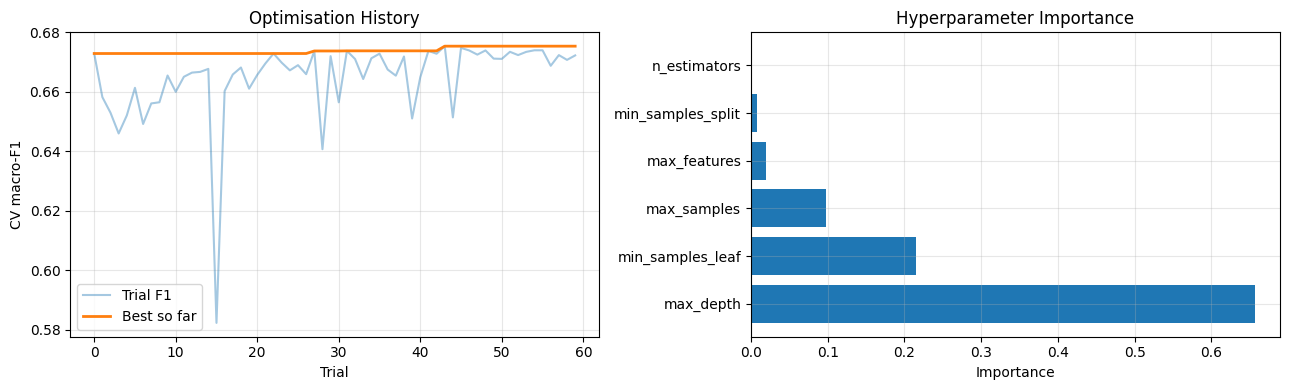

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

#Trial-by-trial best value
values = [t.value for t in study.trials]
best_so_far = np.maximum.accumulate(values)
axes[0].plot(values, alpha=0.4, label="Trial F1")
axes[0].plot(best_so_far, linewidth=2, label="Best so far")
axes[0].set_xlabel("Trial")
axes[0].set_ylabel("CV macro-F1")
axes[0].set_title("Optimisation History")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

#Parameter importance
importances = optuna.importance.get_param_importances(study)
axes[1].barh(list(importances.keys()), list(importances.values()))
axes[1].set_xlabel("Importance")
axes[1].set_title("Hyperparameter Importance")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

####Retrain With Optimized Hyperparameters

In [14]:
print("\nRetraining...")

best_params = {**best.params, "class_weight": "balanced", "random_state": 42, "n_jobs": -1}

rf_best = RandomForestClassifier(**best_params)
rf_best.fit(X_train, y_train)

y_pred_train = rf_best.predict(X_train)
y_pred_test  = rf_best.predict(X_test)

train_acc = accuracy_score(y_train, y_pred_train)
test_acc  = accuracy_score(y_test,  y_pred_test)
test_f1   = f1_score(y_test, y_pred_test, average="macro")

print("Final Eval")
print(f"Train accuracy : {train_acc:.4f}")
print(f"Test  accuracy : {test_acc:.4f}   (baseline: 0.6853)")
print(f"Test macro-F1  : {test_f1:.4f}   (baseline: 0.6810)")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_test))


Retraining...
Final Eval
Train accuracy : 0.9721
Test  accuracy : 0.6863   (baseline: 0.6853)
Test macro-F1  : 0.6814   (baseline: 0.6810)

Classification Report:
                  precision    recall  f1-score   support

  heartbreak_sad       0.53      0.61      0.57       898
        hype_rap       0.81      0.87      0.84       697
     jazz_lounge       0.78      0.70      0.74      1550
rustic_nostalgia       0.60      0.66      0.63       718
     study_focus       0.82      0.69      0.75      1621
summertime_party       0.52      0.61      0.57       939

        accuracy                           0.69      6423
       macro avg       0.68      0.69      0.68      6423
    weighted avg       0.70      0.69      0.69      6423



This did marginally better than the baseline RF model. Due to overfitting here, we'll try manually decreasing Max_depth (According to Bayesian Search, OPT=22).

In [15]:
for depth in [6, 10, 15, 18]:
    rf = RandomForestClassifier(
        n_estimators=400,
        max_depth=depth,
        min_samples_leaf=1,
        min_samples_split=4,
        max_features=0.5,
        max_samples=0.6403590943860158,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1,
    )
    rf.fit(X_train, y_train)
    pred = rf.predict(X_test)
    print(f"max_depth={depth} | Train: {accuracy_score(y_train, rf.predict(X_train)):.4f} | Test: {accuracy_score(y_test, pred):.4f} | F1: {f1_score(y_test, pred, average='macro'):.4f}")

max_depth=6 | Train: 0.6186 | Test: 0.6042 | F1: 0.5993
max_depth=10 | Train: 0.7038 | Test: 0.6480 | F1: 0.6466
max_depth=15 | Train: 0.8639 | Test: 0.6796 | F1: 0.6766
max_depth=18 | Train: 0.9403 | Test: 0.6843 | F1: 0.6807


Despite the disparity in Train/Test Acc growing, it seesm that we improve performance by increasing the max_depth. This verifies Optuna's conclusion of the optimal max_depth=22.

However, notice that we reached our max number of trees in the forest (400). We can experiment to see if we simply were not in the correct search space.

In [23]:
for estimators in [600, 800]:
    rf = RandomForestClassifier(
        n_estimators=estimators,
        max_depth=22,
        min_samples_leaf=1,
        min_samples_split=4,
        max_features=0.5,
        max_samples=0.6403590943860158,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1,
    )
    rf.fit(X_train, y_train)
    pred = rf.predict(X_test)
    print(f"n_estimators={estimators} | Train: {accuracy_score(y_train, rf.predict(X_train)):.4f} | Test: {accuracy_score(y_test, pred):.4f} | F1: {f1_score(y_test, pred, average='macro'):.4f}")

n_estimators=600 | Train: 0.9726 | Test: 0.6861 | F1: 0.6817
n_estimators=800 | Train: 0.9728 | Test: 0.6846 | F1: 0.6800


##LightGBM

In [16]:
!pip install lightgbm

The LightGBM baseline marginally outperformed our hyperparameter-tuned RF with a test accuracy of 68.9% (0.3% higher)

###Baseline Model

In [17]:
import lightgbm as lgb
from sklearn.preprocessing import LabelEncoder

#Encode labels
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc  = le.transform(y_test)

print("Class mapping:")
for i, cls in enumerate(le.classes_):
    print(f" {i} -> {cls}")

lgbm_baseline = lgb.LGBMClassifier(
    n_estimators=300, #same as RF baseline
    learning_rate=0.05,
    max_depth=-1,
    num_leaves=31,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
    verbose=-1,
)

print("\nLightGBM Baseline")
lgbm_baseline.fit(X_train, y_train_enc)

lgbm_pred_train = lgbm_baseline.predict(X_train)
lgbm_pred_test = lgbm_baseline.predict(X_test)

train_acc = accuracy_score(y_train_enc, lgbm_pred_train)
test_acc = accuracy_score(y_test_enc,  lgbm_pred_test)
test_f1 = f1_score(y_test_enc, lgbm_pred_test, average="macro")

print(f"Train accuracy: {train_acc:.4f}")
print(f"Test accuracy: {test_acc:.4f}")
print(f"Test macro-F1: {test_f1:.4f}")
print("\nClassification Report:")
print(classification_report(y_test_enc, lgbm_pred_test, target_names=le.classes_))


Class mapping:
  0 → heartbreak_sad
  1 → hype_rap
  2 → jazz_lounge
  3 → rustic_nostalgia
  4 → study_focus
  5 → summertime_party

LightGBM Baseline
Train accuracy: 0.8933
Test accuracy: 0.6888
Test macro-F1: 0.6854

Classification Report:
                  precision    recall  f1-score   support

  heartbreak_sad       0.52      0.63      0.57       898
        hype_rap       0.81      0.87      0.84       697
     jazz_lounge       0.79      0.69      0.74      1550
rustic_nostalgia       0.59      0.72      0.65       718
     study_focus       0.82      0.68      0.75      1621
summertime_party       0.55      0.59      0.57       939

        accuracy                           0.69      6423
       macro avg       0.68      0.70      0.69      6423
    weighted avg       0.71      0.69      0.69      6423



In [21]:
lgbm_baseline = lgb.LGBMClassifier(
    n_estimators=800, #same as RF baseline
    learning_rate=0.05,
    max_depth=-1,
    num_leaves=31,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
    verbose=-1,
)

print("\nLightGBM Baseline")
lgbm_baseline.fit(X_train, y_train_enc)

lgbm_pred_train = lgbm_baseline.predict(X_train)
lgbm_pred_test = lgbm_baseline.predict(X_test)

train_acc = accuracy_score(y_train_enc, lgbm_pred_train)
test_acc = accuracy_score(y_test_enc,  lgbm_pred_test)
test_f1 = f1_score(y_test_enc, lgbm_pred_test, average="macro")

print(f"Train accuracy: {train_acc:.4f}")
print(f"Test accuracy: {test_acc:.4f}")
print(f"Test macro-F1: {test_f1:.4f}")
print("\nClassification Report:")
print(classification_report(y_test_enc, lgbm_pred_test, target_names=le.classes_))


LightGBM Baseline
Train accuracy: 0.9863
Test accuracy: 0.6933
Test macro-F1: 0.6888

Classification Report:
                  precision    recall  f1-score   support

  heartbreak_sad       0.53      0.62      0.58       898
        hype_rap       0.82      0.86      0.84       697
     jazz_lounge       0.79      0.70      0.74      1550
rustic_nostalgia       0.61      0.70      0.65       718
     study_focus       0.81      0.70      0.75      1621
summertime_party       0.54      0.60      0.57       939

        accuracy                           0.69      6423
       macro avg       0.68      0.70      0.69      6423
    weighted avg       0.71      0.69      0.70      6423



The LightGBM baseline marginally outperformed the Hyperparameter-tuned RF model. However, we seem to be reaching the upper-limit of what is possible with our dataset. Specific categories such as heartbreak_sad and summertime_party may be too broad: every type of genre can have songs with sad lyrics, and people probably like to listen to many different kinds of music during the summer (rap, jazz, country, etc.).

###LightGBM Hyperparameter Tuning

Fine-tuning the hyperparameters of the LightGBM yielded a test accuracy of 69.8%, a
0.9% increase from the baseline model.

In [24]:
import optuna
from optuna.samplers import TPESampler

optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial: optuna.Trial) -> float:
    params = {
        # Number of boosting rounds
        "n_estimators": trial.suggest_int("n_estimators", 100, 600, step=50),

        #Learning rate
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),

        #num_leaves
        "num_leaves": trial.suggest_int("num_leaves", 20, 150),

        #Max depth
        "max_depth": trial.suggest_int("max_depth", 5, 30),

        #Min samples per leaf
        "min_child_samples": trial.suggest_int("min_child_samples", 10, 100),

        #Row subsampling
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),

        #Feature subsampling
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.4, 1.0),

        #L1/L2 reg
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-4, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-4, 10.0, log=True),

        "class_weight": "balanced",
        "random_state": 42,
        "n_jobs": -1,
        "verbose": -1,
    }

    model = lgb.LGBMClassifier(**params)
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    scores = cross_val_score(
        model, X_train, y_train_enc,
        cv=cv,
        scoring="f1_macro",
        n_jobs=-1,
    )
    return scores.mean()

In [26]:
print("LightGBM (Optuna/TPE)")
print(f"Search space: 9 hyperparameters")
print(f"Trials: 40")
print(f"CV folds: 3  (StratifiedKFold, macro-F1)")

sampler = TPESampler(seed=42)
study = optuna.create_study(direction="maximize", sampler=sampler)

# Warm-start with baseline config
study.enqueue_trial({
    "n_estimators": 300,
    "learning_rate": 0.05,
    "num_leaves": 31,
    "max_depth": 10,
    "min_child_samples": 20,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "reg_alpha": 0.01,
    "reg_lambda": 0.01,
})

study.optimize(objective, n_trials=40, show_progress_bar=True)

LightGBM (Optuna/TPE)
Search space: 9 hyperparameters
Trials: 40
CV folds: 3  (StratifiedKFold, macro-F1)


  0%|          | 0/40 [00:00<?, ?it/s]

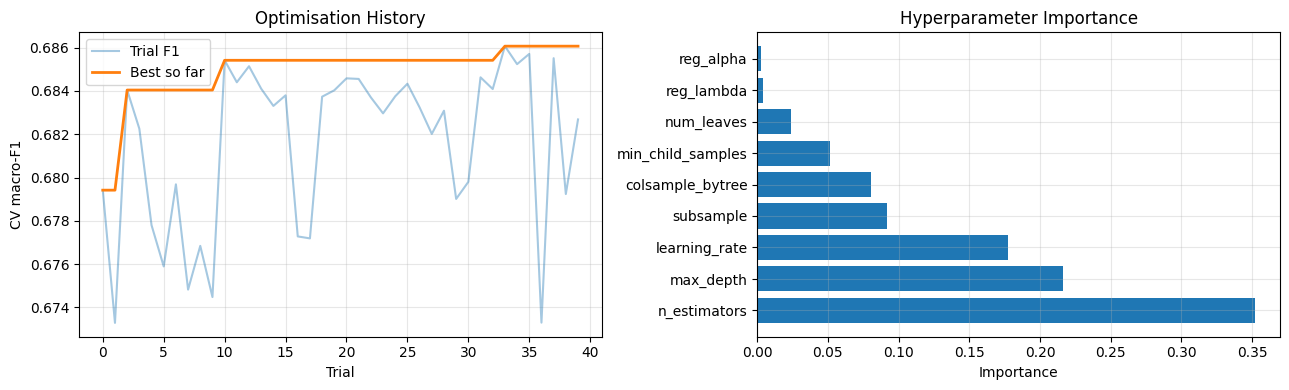

Best trial
  CV macro-F1 : 0.6861
  Params:
    n_estimators              = 600
    learning_rate             = 0.012128879973611789
    num_leaves                = 120
    max_depth                 = 30
    min_child_samples         = 64
    subsample                 = 0.9140372819255408
    colsample_bytree          = 0.5210953958341624
    reg_alpha                 = 0.004971292513094587
    reg_lambda                = 0.03577543513620776


In [27]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

values = [t.value for t in study.trials]
best_so_far = np.maximum.accumulate(values)
axes[0].plot(values, alpha=0.4, label="Trial F1")
axes[0].plot(best_so_far, linewidth=2, label="Best so far")
axes[0].set_xlabel("Trial")
axes[0].set_ylabel("CV macro-F1")
axes[0].set_title("Optimisation History")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

importances = optuna.importance.get_param_importances(study)
axes[1].barh(list(importances.keys()), list(importances.values()))
axes[1].set_xlabel("Importance")
axes[1].set_title("Hyperparameter Importance")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
# plt.savefig("optuna_lgbm_results.png", dpi=150, bbox_inches="tight")
# print("\nSaved optimisation plot → optuna_lgbm_results.png")
plt.show()

print("Best trial")
best = study.best_trial
print(f"  CV macro-F1 : {best.value:.4f}")
print(f"  Params:")
for k, v in best.params.items():
    print(f"    {k:25s} = {v}")

In [28]:
print("\nRetraining...")

best_params = {
    **best.params,
    "class_weight": "balanced",
    "random_state": 42,
    "n_jobs": -1,
    "verbose": -1,
}

lgbm_best = lgb.LGBMClassifier(**best_params)
lgbm_best.fit(X_train, y_train_enc)

lgbm_pred_train = lgbm_best.predict(X_train)
lgbm_pred_test  = lgbm_best.predict(X_test)

train_acc = accuracy_score(y_train_enc, lgbm_pred_train)
test_acc  = accuracy_score(y_test_enc,  lgbm_pred_test)
test_f1   = f1_score(y_test_enc, lgbm_pred_test, average="macro")

print("Tuned LightGBM")
print(f"Train accuracy: {train_acc:.4f}")
print(f"Test  accuracy: {test_acc:.4f}   (baseline: 0.6888)")
print(f"Test macro-F1: {test_f1:.4f}   (baseline: 0.6854)")
print("\nClassification Report:")
print(classification_report(y_test_enc, lgbm_pred_test, target_names=le.classes_))


Retraining...
Tuned LightGBM
Train accuracy: 0.9626
Test  accuracy: 0.6981   (baseline: 0.6888)
Test macro-F1: 0.6946   (baseline: 0.6854)

Classification Report:
                  precision    recall  f1-score   support

  heartbreak_sad       0.54      0.64      0.59       898
        hype_rap       0.82      0.87      0.84       697
     jazz_lounge       0.81      0.70      0.75      1550
rustic_nostalgia       0.62      0.70      0.66       718
     study_focus       0.82      0.70      0.75      1621
summertime_party       0.54      0.62      0.58       939

        accuracy                           0.70      6423
       macro avg       0.69      0.71      0.69      6423
    weighted avg       0.71      0.70      0.70      6423

